In [1]:
# from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
import os, psutil 
def show_ram():
    proc = psutil.Process(os.getpid())
    rss = proc.memory_info().rss
    print(f"Notebook RAM usage: {rss/1e9:.2f} GB")

show_ram()


Notebook RAM usage: 0.06 GB


In [3]:
import os
import gc
import glob
import numpy as np
import healpy as hp
import matplotlib
import hera_pspec as hp
from scipy import stats
import hera_cal as hc
from astropy import constants
from pyuvdata import utils as uvutils
from pyuvdata import UVData
import matplotlib.pyplot as plt
import itertools
from pyuvdata import UVData, UVCal

import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
import h5py
import hdf5plugin  # REQUIRED to have the compression plugins available
import numpy as np
from scipy import constants, interpolate
import copy
import glob
import re
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
pd.set_option('display.max_rows', 1000)
from uvtools.plot import plot_antpos, plot_antclass
from hera_qm import ant_metrics, ant_class, xrfi
from hera_cal import io, utils, redcal, apply_cal, datacontainer, abscal
from hera_filters import dspec
from IPython.display import display, HTML
import linsolve
# display(HTML("<style>.container { width:100% !important; }</style>"))
# _ = np.seterr(all='ignore')  # get rid of red warnings
# %config InlineBackend.figure_format = 'retina'

# this enables better memory management on linux
import ctypes
def malloc_trim():
    try:
        ctypes.CDLL('libc.so.6').malloc_trim(0) 
    except OSError:
        pass
    
import sys

from copy import deepcopy
from datetime import datetime
import time

matplotlib.rcParams["mathtext.fontset"] = "cm"
matplotlib.rcParams["font.family"] = "STIXGeneral"
matplotlib.rcParams["font.size"] = "18"
from matplotlib.ticker import MultipleLocator


####################################################################################################################################################################################################################################################################################

for repo in ['numpy', 'scipy', 'astropy', 'hera_cal', 'hera_qm', 'hera_filters', 'pyuvdata', 'hera_pspec']:
    exec(f'from {repo} import __version__')
    print(f'{repo}: {__version__}')
    
# Old hera_filter version : ValueError: ridge_alpha is not a valid argument!valid arguments include ['suppression_factors', 'eigenval_cutoff', 'max_contiguous_edge_flags'] : Version hera_filters: 0.1.3
# Latest version working 24 Nov 24 : hera_filters: 0.1.6.dev1+g297dcce
# How to update :
# conda activate <hera>
# pip install --upgrade hera-filters
# python -c "import hera_filters; print(hera_filters.__version__)"

# pip install --upgrade hera-filters --user
# pip install git+https://github.com/HERA-Team/hera_filters.git

# pld hera_pspec: 0.4.2.dev4+gc34b82e

numpy: 1.26.4
scipy: 1.14.0
astropy: 6.1.2
hera_cal: 3.7.4
hera_qm: 2.2.0
hera_filters: 0.1.5
pyuvdata: 3.2.0
hera_pspec: 0.4.3.dev89+ge63e2a188


In [4]:
# All H4C dependencies

# import numpy as np
import matplotlib.pyplot as plt
# To run pspecdata.pspec_run
from hera_pspec import PSpecContainer
from hera_pspec import utils as pspec_utils
from hera_pspec import pspecdata, pstokes
from hera_pspec import uvpspec

# To run io.HERAdata etc
from hera_cal import frf, delay_filter, io, smooth_cal

# import glob, tqdm, os, copy
import glob, os, copy
import functools
import time

from hera_qm import utils
from astropy import units

from matplotlib.colors import LogNorm
from hera_cal import apply_cal
from pyuvdata import UVBeam, UVData
from hera_pspec import grouping
import warnings
# To run datetime.now() function
from datetime import datetime
from hera_pspec.conversions import Cosmo_Conversions as cc
from hera_cal import lstbin
from hera_cal import frf
import scipy.interpolate as interp
from hera_cal.vis_clean import VisClean

from pathlib import Path

SDAY_KSEC = units.sday.to("ks")

In [5]:
# import numpy as np
# np.set_printoptions(linewidth=370)  # or any large number that suits your screen


In [ ]:
pol_root=['xx']#, 'yy']
proc1 = ["cutbl"]#, "allbl"]
proc2 = ["cutlst"]#, "alllst"]

run_batch = ['250925']

# sky_type = "ptsrc"
# sky_type = "eor"

In [52]:
import h5py

def dat_globber_multi(bl_len, bl_ang, pol_read):
    
    print("pol_read ", pol_read)
    
#     OUTPUT_DIR = '/home/herastore02-1/H6C_scratch_rchandra/Sig_Loss_1'
#     OUTPUT_DIR = '/home/herastore02-1/H6C_scratch_rchandra/Sig_Loss_1_pI/' 
#     OUTPUT_DIR = '/home/herastore02-1/H6C_scratch_rchandra/Sig_Loss_1_xx/' 
    OUTPUT_DIR = f'output_vis_sigloss_check_out/Sig_Loss_{run_batch[0]}_{pol_read}/' 
    print("OUTPUT_DIR ", OUTPUT_DIR)
    
#     pol='pI'
#     pol='xx'
#     pol='yy'
    
#     proc1 = ["cutbl", "allbl"]
    
    # PTSRC SKY

    # ideal ENU, ideal Airy                               airyred, idealT
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airyred")
    # real ENU, ideal Airy                                airyred, idealF
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airyred")
    # ideal ENU, diameter Airy var (deltaD ~ <.2m)        airyprb, idealT
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airyprb")
    # real ENU, diameter Airy var (deltaD ~ <.2m)         airyprb, idealF
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airyprb")
    # ideal ENU, tilt Airy var (deltZa ~ 2-3 degree)      airytilt, idealT
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")
    # real ENU, tilt Airy var (deltZa ~ 2-3 degree)       airytilt, idealF
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")

    # Vivaldi
    # ideal ENU, ideal Vivaldi       vivaldired, idealT
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_vivaldired")
    # real ENU, ideal Vivaldi       vivaldired, idealF
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_vivaldired")

    # EOR SKY

    # ideal ENU, tilt Airy var (deltZa ~ 2-3 degree)       airytilt, idealT
    # MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")
    # real ENU, tilt Airy var (deltZa ~ 2-3 degree)       airytilt, idealF
    # MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")

    # Vivaldi
    # ideal ENU, ideal Vivaldi       vivaldired, idealT
    # MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_vivaldired")
    # real ENU, ideal Vivaldi       vivaldired, idealF
    MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_vivaldired")

    # sky_type = "ptsrc"    
    sky_type = "eor"

    # Get just the last path component
    base = MODEL_DIR.name
    # Extract ideal tag: after "subset_" and before the next "_"
    m_ideal = re.search(r"subset_([^_]+)", base)
    ideal_tag = m_ideal.group(1) if m_ideal else "ideal"
    # Extract airy tag: after "nonred_" to the end (no more "_")
    m_airy = re.search(r"nonred_([^_]+)$", base)
    airy_tag = m_airy.group(1) if m_airy else "airy"
    print("ideal_tag:", ideal_tag)  
    print("airy_tag :", airy_tag) 

    batchnum = 0 
    input_datfile_list = sorted(glob.glob(os.path.join(OUTPUT_DIR, f"notebook_{sky_type}_{ideal_tag}_{airy_tag}_Coh_PSPEC_{bl_len}_{bl_ang}_{pol_read}_{proc1[0]}_{proc2[0]}_bch_{batchnum}_psc_PN.h5" )))

    print(f"notebook_{sky_type}_{ideal_tag}_{airy_tag}_Coh_PSPEC_{bl_len}_{bl_ang}_{pol_read}_{proc1[0]}_{proc2[0]}_bch_{batchnum}_psc_PN.h5")
    print("input_datfile_list ", input_datfile_list[0:10])
    
    print("bl_len, bl_ang ", bl_len, bl_ang)
    uvps_dat_list = []
    start = time.time()
    for fname in input_datfile_list: 
#         print("fname ", fname)
        uvpsi = {}
        psci = PSpecContainer(filename=fname, mode='r', keep_open=False)
#         print(psci.groups() )
        uvpsi = psci.get_pspec('dset0', 'dset0_x_dset0' )
#         print("uvpsi ", uvpsi)
#         print( psci.groups )
        uvps_dat_list.append(uvpsi)
    end = time.time()
    print(end - start)
    
#     for fname in input_datfile_list: 
#         with h5py.File(fname, 'r') as f:
#             # List the top-level groups/datasets in the file
#             print("Top-level keys:", list(f.keys()))
#             print("f ", f)
            
#             uvps_dat_list.append(f)

            # Suppose there is a group called 'mygroup', you can access it like this:
#             if 'data_spw0' in f:
#                 mygroup = f['data_spw0']
#                 print(mygroup)
#                 # print("Keys in 'mygroup':", list(mygroup.keys()))


    print("uvps_dat_list ", uvps_dat_list[20:23] )
    # global uvp 
    print("Combining ___________________________________")
    # Indices to remove
    indices_to_remove = {} 
    new_list = [value for idx, value in enumerate(uvps_dat_list) if idx not in indices_to_remove]    
    uvp  = uvpspec.combine_uvpspec(new_list, merge_history=True, verbose=False)
    print( uvp.get_blpairs() )
    return uvp

#     print("uvps_dat_tot ", uvps_dat_tot)
    
    

In [53]:
# bl_len = [25, 29, 44] #, 38]
# bl_ang = [90, 0, 0] #, 161]

# bl_len = [ 15.0, 25.0 ]
# bl_ang = [ 0.0, 150.0 ]

# bl_len = [25, 25, 29, 44]
# bl_ang = [90, 150, 0, 120]

# bl_len = [15, 25, 25, 29, 29, 29, 39, 39, 39, 39, 44, 44, 44, 51, 51, 53, 53, 53, 53, 58, 58, 64, 64, 64, 67, 67, 67, 67, 73, 73, 76, 77, 77, 81, 88]
# bl_ang = [0, 150, 30, 0, 60, 120, 19, 161, 139, 41, 0, 60, 120, 30, 150, 166, 14, 46, 134, 0, 120, 144, 157, 24, 169, 11, 109, 131, 0, 120, 150, 161, 139, 171, 0]

# bl_len = [39, 64, 64, 64, 67, 67, 67,  88]
# bl_ang = [41, 144, 157, 24, 169, 109, 131, 0]

bl_len = [14.0]#, 25, 25, 29, 29, 29, 39, 39, 39, 39, 44, 44, 44, 51, 51, 53, 53, 53, 53, 58, 58 ] 
bl_ang = [0.0]#, 150, 30, 0, 60, 120, 19, 161, 139, 41, 0, 60, 120, 30, 150, 166, 14, 46, 134, 0, 120 ] 

# Loop over the N values and store each combined uvp in a dictionary.
combined_uvp_dict = {}
for pol_in in (pol_root):
    print("pol_in ", pol_in)
    for i in range(len(bl_len)):
        print("i ", i, bl_len[i],bl_ang[i], pol_in)
        uvp = dat_globber_multi(bl_len[i],bl_ang[i], pol_in)
        if uvp is not None:
            combined_uvp_dict[(bl_len[i],bl_ang[i],pol_in)] = uvp

pol_in  xx
i  0 14.0 0.0 xx
pol_read  xx
OUTPUT_DIR  output_vis_sigloss_check_out/Sig_Loss_250925_xx/
ideal_tag: idealF
airy_tag : vivaldired
notebook_eor_idealF_vivaldired_Coh_PSPEC_14.0_0.0_xx_cutbl_cutlst_bch_0_psc_PN.h5
input_datfile_list  ['output_vis_sigloss_check_out/Sig_Loss_250925_xx/notebook_eor_idealF_vivaldired_Coh_PSPEC_14.0_0.0_xx_cutbl_cutlst_bch_0_psc_PN.h5']
bl_len, bl_ang  14.0 0.0
0.1553506851196289
uvps_dat_list  []
Combining ___________________________________
[((0, 1), (0, 1))]


In [54]:
print(combined_uvp_dict)
for pol_in in (pol_root):
    for i in range(len(bl_len)):
        print(combined_uvp_dict[(bl_len[i],bl_ang[i],pol_in)])
    
# print(uvp)
# access each combined uvp by its N value.
# for bl_len, uvp_obj in combined_uvp_dict.items():
#     print(f"N = {bl_len}: combined uvp keys: {list(uvp_obj.keys())}")

{(14.0, 0.0, 'xx'): <hera_pspec.uvpspec.UVPSpec object at 0x7fd3b0b6b9d0>}
 ATTRIBUTES
------------
          Nblpairs: 1
              Nbls: 1
         Nbltpairs: 720
             Ndlys: 88
            Nfreqs: 88
             Npols: 1
          Nspwdlys: 88
         Nspwfreqs: 88
             Nspws: 1
            Ntimes: 720
           Ntpairs: 720
        beam_freqs: shape (201,)
     channel_width: shape (89,)
             cosmo: Cosmo_Conversions object at <0x7fd3b0b73610>
Om_L : 0.6844; Om_b : 0.0491; Om_c : 0.2644; Om_M : 0.3135; Om_k : 0.0021; H0 : 67.2700
         dly_array: shape (88,)
     exact_windows: False
            folded: False
        freq_array: shape (88,)
            labels: shape (1,)
              norm: I
        norm_units: h^-3 Mpc^3
     polpair_array: shape (1,)
          r_params: 
      scalar_array: shape (1, 1)
         spw_array: shape (1,)
             taper: blackman-harris
telescope_location: shape (3,)
         vis_units: mK
         weighting: iden

In [55]:
import h5py

def dat_globber_multi(bl_len, bl_ang, pol_read):
    
#     OUTPUT_DIR = '/home/herastore02-1/H6C_scratch_rchandra/Sig_Loss_1'
#     OUTPUT_DIR = '/home/herastore02-1/H6C_scratch_rchandra/Sig_Loss_1_pI/' 
#     OUTPUT_DIR = '/home/herastore02-1/H6C_scratch_rchandra/Sig_Loss_1_xx/' 
#     OUTPUT_DIR = f'/home/herastore02-1/H6C_scratch_rchandra/Sig_Loss_1_{pol_read}/' 
    OUTPUT_DIR = f'output_vis_sigloss_check_out/Sig_Loss_{run_batch[0]}_{pol_read}/' 

    
#     pol='pI'
#     pol='xx'
#     pol='yy'
    
#     proc1 = ["cutbl", "allbl"]

    
    # ideal ENU, ideal Airy                               airyred, idealT
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airyred")
    # real ENU, ideal Airy                                airyred, idealF
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airyred")
    # ideal ENU, diameter Airy var (deltaD ~ <.2m)        airyprb, idealT
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airyprb")
    # real ENU, diameter Airy var (deltaD ~ <.2m)         airyprb, idealF
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airyprb")
    # ideal ENU, tilt Airy var (deltZa ~ 2-3 degree)      airytilt, idealT
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")
    # real ENU, tilt Airy var (deltZa ~ 2-3 degree)       airytilt, idealF
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")

    # Vivaldi
    # ideal ENU, ideal Vivaldi       vivaldired, idealT
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_vivaldired")
    # real ENU, ideal Vivaldi       vivaldired, idealF
    # MODEL_DIR   = Path("ptsrc256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_vivaldired")

    # EOR SKY

    # ideal ENU, tilt Airy var (deltZa ~ 2-3 degree)       airytilt, idealT
    # MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")
    # real ENU, tilt Airy var (deltZa ~ 2-3 degree)       airytilt, idealF
    # MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_airytilt")

    # Vivaldi
    # ideal ENU, ideal Vivaldi       vivaldired, idealT
    # MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_idealT_cba81417555edaffd87557575713cb61.txt-nonred_vivaldired")
    # real ENU, ideal Vivaldi       vivaldired, idealF
    MODEL_DIR   = Path("eor-grf-256/nt17280-00288chunks-HERA_custom_subset_idealF_cba81417555edaffd87557575713cb61.txt-nonred_vivaldired")
    
    # sky_type = "ptsrc"    
    sky_type = "eor"

    # Get just the last path component
    base = MODEL_DIR.name
    # Extract ideal tag: after "subset_" and before the next "_"
    m_ideal = re.search(r"subset_([^_]+)", base)
    ideal_tag = m_ideal.group(1) if m_ideal else "ideal"
    # Extract airy tag: after "nonred_" to the end (no more "_")
    m_airy = re.search(r"nonred_([^_]+)$", base)
    airy_tag = m_airy.group(1) if m_airy else "airy"
    print("ideal_tag:", ideal_tag)  
    print("airy_tag :", airy_tag) 

    batchnum = 0 
    input_datfile_list = sorted(glob.glob(os.path.join(OUTPUT_DIR, f"notebook_{sky_type}_{ideal_tag}_{airy_tag}_Incoh_PSPEC_{bl_len}_{bl_ang}_{pol_read}_{proc1[0]}_{proc2[0]}_bch_{batchnum}_psc_PN.h5" )))

    print(f"notebook_{sky_type}_{ideal_tag}_{airy_tag}_Incoh_PSPEC_{bl_len}_{bl_ang}_{pol_read}_{proc1[0]}_{proc2[0]}_bch_{batchnum}_psc_PN.h5")

    print("input_datfile_list ", input_datfile_list[0:10])

    print("bl_len, bl_ang ", bl_len, bl_ang)
    
    uvps_dat_list = []
    start = time.time()
    for fname in input_datfile_list: 
        uvpsi = {}
        psci = PSpecContainer(filename=fname, mode='r', keep_open=False)
#         print(psci.groups() )
        uvpsi = psci.get_pspec('dset0', 'dset0_x_dset0' )
#         print("uvpsi ", uvpsi)
#         print( psci.groups )
        uvps_dat_list.append(uvpsi)
    end = time.time()
    print(end - start)
    
#     for fname in input_datfile_list: 
#         with h5py.File(fname, 'r') as f:
#             # List the top-level groups/datasets in the file
#             print("Top-level keys:", list(f.keys()))
#             print("f ", f)
            
#             uvps_dat_list.append(f)

            # Suppose there is a group called 'mygroup', you can access it like this:
#             if 'data_spw0' in f:
#                 mygroup = f['data_spw0']
#                 print(mygroup)
#                 # print("Keys in 'mygroup':", list(mygroup.keys()))


#     print("uvps_dat_list ", uvps_dat_list)
    # global uvpspec_averaged 
    print("Combining ___________________________________")
    uvpspec_averaged  = uvpspec.combine_uvpspec(uvps_dat_list, merge_history=True, verbose=False)
    print( uvpspec_averaged.get_blpairs() )
    return uvpspec_averaged
    
#     print("uvps_dat_tot ", uvps_dat_tot)
    
    

In [56]:
# bl_len = [25, 29, 44] #, 38]
# bl_ang = [90, 0, 0] #, 161]

# bl_len = [ 15.0, 25.0 ]
# bl_ang = [ 0.0, 150.0 ]

# bl_len = [25, 25, 29, 44]
# bl_ang = [90, 150, 0, 120]

# bl_len = [15, 25, 25, 29, 29, 29, 39, 39, 39, 39, 44, 44, 44, 51, 51, 53, 53, 53, 53, 58, 58, 64, 64, 64, 67, 67, 67, 67, 73, 73, 76, 77, 77, 81, 88]
# bl_ang = [0, 150, 30, 0, 60, 120, 19, 161, 139, 41, 0, 60, 120, 30, 150, 166, 14, 46, 134, 0, 120, 144, 157, 24, 169, 11, 109, 131, 0, 120, 150, 161, 139, 171, 0]

# bl_len = [39, 64, 64, 64, 67, 67, 67,  88]
# bl_ang = [41, 144, 157, 24, 169, 109, 131, 0]

bl_len = [14.0]#, 25, 25, 29, 29, 29, 39, 39, 39, 39, 44, 44, 44, 51, 51, 53, 53, 53, 53, 58, 58 ] 
bl_ang = [0.0]#, 150, 30, 0, 60, 120, 19, 161, 139, 41, 0, 60, 120, 30, 150, 166, 14, 46, 134, 0, 120 ] 

# Loop over the N values and store each combined uvp in a dictionary.
combined_uvp_avg_dict = {}
for pol_in in (pol_root):
    print("pol_in ", pol_in)
    for i in range(len(bl_len)):
        uvp_avg = dat_globber_multi(bl_len[i], bl_ang[i], pol_in)
        if uvp is not None:
            combined_uvp_avg_dict[(bl_len[i],bl_ang[i], pol_in)] = uvp_avg

pol_in  xx
ideal_tag: idealF
airy_tag : vivaldired
notebook_eor_idealF_vivaldired_Incoh_PSPEC_14.0_0.0_xx_cutbl_cutlst_bch_0_psc_PN.h5
input_datfile_list  ['output_vis_sigloss_check_out/Sig_Loss_250925_xx/notebook_eor_idealF_vivaldired_Incoh_PSPEC_14.0_0.0_xx_cutbl_cutlst_bch_0_psc_PN.h5']
bl_len, bl_ang  14.0 0.0
0.17581534385681152
Combining ___________________________________
[((0, 1), (0, 1))]


In [57]:
for pol_in in (pol_root):
    for i in range(len(bl_len)):
        print(combined_uvp_avg_dict[(bl_len[i],bl_ang[i],pol_in)])

 ATTRIBUTES
------------
          Nblpairs: 1
              Nbls: 1
         Nbltpairs: 720
             Ndlys: 88
            Nfreqs: 88
             Npols: 1
          Nspwdlys: 88
         Nspwfreqs: 88
             Nspws: 1
            Ntimes: 720
           Ntpairs: 720
        beam_freqs: shape (201,)
     channel_width: shape (89,)
             cosmo: Cosmo_Conversions object at <0x7fd3b0b7f490>
Om_L : 0.6844; Om_b : 0.0491; Om_c : 0.2644; Om_M : 0.3135; Om_k : 0.0021; H0 : 67.2700
         dly_array: shape (88,)
     exact_windows: False
            folded: False
        freq_array: shape (88,)
            labels: shape (1,)
              norm: I
        norm_units: h^-3 Mpc^3
     polpair_array: shape (1,)
          r_params: 
      scalar_array: shape (1, 1)
         spw_array: shape (1,)
             taper: blackman-harris
telescope_location: shape (3,)
         vis_units: mK
         weighting: identity

 DATASETS
------------
       lst_1_array: shape (720,)
       lst_2_

In [58]:
# pol='yy'

# Must be obtained from collect_num_baselines.sh

# nbls_counts_xx = [81 , 50 , 44 , 56 , 38 , 42 , 29 , 36 , 32 , 22 , 40 , 20 , 24 , 17 , 23 , 24 , 22 , 15 , 17 , 30 , 12 , 13 , 15 , 15 , 25 , 17 , 5 , 8 , 20 , 4 , 8 , 11 , 5 , 20 , 16]

# nbls_counts_xx = [ 22, 13 , 15 , 15 , 25 , 5 , 8, 16]

# nbls_counts_xx = [81 , 50 , 44 , 56 , 38 , 42 , 29 , 36 , 32 , 22 , 40 , 20 , 24 , 17 , 23 , 24 , 22 , 15 , 17 , 30 , 12 ]



# nbls_counts_yy = [81 , 50 , 44 , 56 , 38 , 42 , 29 , 36 , 32 , 22 , 40 , 20 , 24 , 17 , 23 , 24 , 22 , 15 , 17 , 30 , 12 , 13 , 15 , 15 , 25 , 17 , 5 , 8 , 20 , 4 , 8 , 11 , 5 , 20 , 16]

nbls_counts = [8]#1 , 50 , 44 , 56 , 38 , 42 , 29 , 36 , 32 , 22 , 40 , 20 , 24 , 17 , 23 , 24 , 22 , 15 , 17 , 30 , 12]

print(nbls_counts)

[8]


In [59]:
# --- all 14 bands -------------------------------------------------
center_z_all = [
    24.6, 19.9, 16.8, 11.7, 10.8,  9.9,  8.9,
     8.2,  7.6,  7.1,  6.5,  6.0,  5.6,  5.2
]

avg_freq_all_MHz = [
   (50.2 +  62.2)/2,   #  56.20
   (63.3 +  73.5)/2,   #  68.40
   (74.6 +  85.4)/2,   #  80.00
  (108.0 + 116.1)/2,   # 112.05
  (117.3 + 124.4)/2,   # 120.85
  (125.4 + 136.2)/2,   # 130.80
  (138.3 + 148.2)/2,   # 143.25
  (150.1 + 159.2)/2,   # 154.65
  (159.3 + 169.9)/2,   # 164.60
  (171.9 + 181.1)/2,   # 176.50
  (181.4 + 196.4)/2,   # 188.90
  (198.5 + 208.4)/2,   # 203.45
  (212.3 + 220.6)/2,   # 216.45
  (224.3 + 231.1)/2    # 227.70
]

# --- only the 8 bands flagged “Used ✓” ----------------------------
center_z_used = [
    24.6, 19.9, 16.8, 10.8,  9.9,  7.6,  7.1,  5.6
]

avg_freq_used_MHz = [
   (50.2 +  62.2)/2,   #  56.20
   (63.3 +  73.5)/2,   #  68.40
   (74.6 +  85.4)/2,   #  80.00
  (117.3 + 124.4)/2,   # 120.85
  (125.4 + 136.2)/2,   # 130.80
  (159.3 + 169.9)/2,   # 164.60
  (171.9 + 181.1)/2,   # 176.50
  (212.3 + 220.6)/2    # 216.45
]


spw_ranges  {0: (74630737.3046875, 85250854.4921875)}
bl_vec  [  5.31007062 -13.60856477  -0.04784431]
key  (0, ((0, 1), (0, 1)), 'xx')
uvp_pow_block  [1018745.93380988 1022666.43949906 1024798.93711894 1025149.09174402
 1027824.58083837 1027585.18124075 1030574.57256167 1032278.65932157
 1033011.57276702 1034194.72433727 1036658.04074344 1037274.4811706
 1039508.47072032 1040022.80208519 1041192.96285124 1042817.54049924
 1044110.34784449 1043681.94114824 1046619.71007018 1046730.82150676
 1048595.08789929 1048785.63669881 1048733.8289161  1050438.19540891
 1051565.66506836 1052752.80347845 1054629.94529303 1055578.94973022
 1057354.47446309 1057812.88461173 1058030.77679334 1058431.16683186
 1062146.66614806 1061431.2501131  1060833.19838897 1062774.32104023
 1061899.4714096  1062611.04728493 1064349.0476666  1064043.91200347
 1066049.20789818 1065446.09547304 1066401.4544722  1068177.72160088
 1067005.46162707 1067214.76024402 1067257.39081784 1069168.62008527
 1067116.1572601  1068

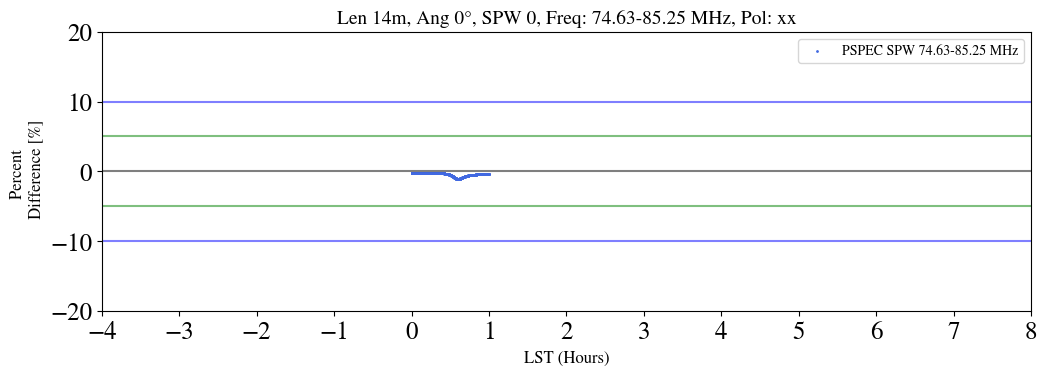

In [60]:
# %matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

def get_spw_info(uvp):
    """
    Returns a dictionary mapping each spw index to its (min, max) frequency range (in Hz).
    """
    spw_indices = uvp.spw_array   # e.g., shape (14,)
    freq = uvp.freq_array         # e.g., shape (1114,)
    spw_freq = uvp.spw_freq_array # e.g., shape (1114,)
    
    spw_ranges = {}
    for spw in spw_indices:
        mask = (spw_freq == spw)
        if np.any(mask):
            freq_min = np.min(freq[mask])
            freq_max = np.max(freq[mask])
            spw_ranges[spw] = (freq_min, freq_max)
        else:
            spw_ranges[spw] = None
    return spw_ranges

def get_plot_data(uvp, uvpspec_averaged, pol, idx):
    """
    Returns a dictionary mapping each spw index to its (min, max) frequency range (in Hz).
    """
    blp = uvp.get_blpairs()[0]
    # key = (idx, blp, 'xx')
    key = (idx, blp, pol)

    # Retrieve LST array and convert to hours.
    tarr = uvp.lst_avg_array
    tarrq = tarr * (12 / np.pi)  # Convert from radians to hours.
    lst_array_rad = tarr
#         print("lst_array_rad ", lst_array_rad)
    lst_array = tarrq

    dlys = uvp.get_dlys(idx) * 1e9
    index_of_zero = np.where(np.isclose(dlys, 0))[0][0]

    uvp_power = np.abs(np.real(uvp.get_data(key)))[:, index_of_zero]
    uvpspec_averaged_power = np.abs(np.real(uvpspec_averaged.get_data(key)))[:, index_of_zero]

    percent_diff = 100 * (uvp_power - uvpspec_averaged_power) / np.where(uvpspec_averaged_power != 0, uvpspec_averaged_power, np.nan)
    median_val = np.nanmedian(percent_diff)
    median_vals.append(median_val)
    mean_val = np.nanmean(percent_diff)
    mean_vals.append(mean_val)

    lst_array_roll = np.where(lst_array > 20, lst_array - 24, lst_array)
        
    return dlys, index_of_zero, lst_array_rad, lst_array, lst_array_roll, uvp_power, uvpspec_averaged_power, percent_diff, mean_vals


def get_plot_data_all_blpairs(uvp, uvp_avg, pol, spw):
    """
    Gather τ≈0 spectra from *all* baseline–pairs, concatenate by LST,
    and compute percent-difference between uvp and its averaged version.

    Parameters
    ----------
    uvp, uvp_avg : UVPSpec
        Original and incoherently-averaged spectra.
    pol          : str              (e.g. 'xx' or 'pI')
    spw          : int              (spectral-window index)

    Returns
    -------
    dlys               : (Ndlys,)  delay values [ns]
    zero_idx           : int       index of τ≈0 in `dlys`
    lst_rad_sorted     : (Ntimes,) LST in radians, sorted
    lst_hr_sorted      : (Ntimes,) LST in hours,  "
    uvp_pow_sorted     : (Ntimes,) |P|  from uvp          (τ≈0)
    uvp_avg_pow_sorted : (Ntimes,) |P|  from uvp_avg      (τ≈0)
    pct_diff_sorted    : (Ntimes,) 100*(uvp-avg)/avg
    mean_pct           : float      mean of pct_diff
    median_pct         : float      median of pct_diff
    """
    # ---------- fixed per-spw info ----------
    dlys = uvp.get_dlys(spw) * 1e9          # ns
    zero_idx = int(np.where(np.isclose(dlys, 0))[0][0])

    # ---------- gather blocks ----------
    lst_list         = []
    uvp_pow_list     = []
    uvp_avg_pow_list = []

    for blp in uvp.get_blpairs():
        key = (spw, blp, pol)
        print("key ", key)

        # LST (radians) and convert now (same for both uvp and uvp_avg)
        lst_block = uvp.lst_avg_array[uvp.blpair_to_indices(blp)]
        lst_list.append(lst_block)

        # spectra, pick τ≈0 and |.| for power
        uvp_pow_block     = np.abs(np.real(uvp        .get_data(key)))[:, zero_idx]
        print("uvp_pow_block ", uvp_pow_block)
        uvp_avg_pow_block = np.abs(np.real(uvp_avg    .get_data(key)))[:, zero_idx]
        print("uvp_avg_pow_block ", uvp_avg_pow_block)

        uvp_pow_list    .append(uvp_pow_block)
        uvp_avg_pow_list.append(uvp_avg_pow_block)

    # ---------- concatenate and sort by LST ----------
    lst_all         = np.concatenate(lst_list)
    uvp_pow_all     = np.concatenate(uvp_pow_list)
    uvp_avg_pow_all = np.concatenate(uvp_avg_pow_list)

    order           = np.argsort(lst_all)
    lst_rad_sorted  = lst_all        [order]
    uvp_pow_sorted  = uvp_pow_all    [order]
    uvp_avg_sorted  = uvp_avg_pow_all[order]

    # ---------- compute percent difference ----------
    pct_diff_sorted = 100.0 * (uvp_pow_sorted - uvp_avg_sorted) / np.where(
                         uvp_avg_sorted != 0, uvp_avg_sorted, np.nan
                     )

    mean_pct   = np.nanmean(pct_diff_sorted)
    median_pct = np.nanmedian(pct_diff_sorted)

    # LST in hours
    lst_hr_sorted = lst_rad_sorted * (12 / np.pi)
    
    lst_array_roll = np.where(lst_hr_sorted > 20, lst_hr_sorted - 24, lst_hr_sorted)

    return (dlys, zero_idx,
            lst_rad_sorted, lst_hr_sorted, lst_array_roll,
            uvp_pow_sorted, uvp_avg_sorted,
            pct_diff_sorted, mean_pct, median_pct)


median_vals = []
mean_vals = []

def plot_percent_difference(combined_uvp_dict, combined_uvp_avg_dict, zero_delay_pspec_spw=None, avg_pspec=None):
    """
    Plot percent difference between uvp and uvpspec_averaged versus LST for each SPW.
    The title and legend include:
      - The baseline length (in m)
      - The baseline angle (forced to 0° here)
      - The SPW index and its full frequency range (in MHz)
      - The polarization used.
    """
    # for grp_key in combined_uvp_dict:
    #     print("grp_key ", grp_key, grp_key[2])
    #     pol_in=grp_key[2]
    #     spw_ranges = get_spw_info(combined_uvp_dict[grp_key])
    example_uvp = next(iter(combined_uvp_dict.values()))
    spw_ranges = get_spw_info(example_uvp)
    print("spw_ranges ", spw_ranges)
    num_spws = len(spw_ranges)
    fig, axes = plt.subplots(5, 3, figsize=(30, 18), sharex=False)
    axes = axes.flatten(order='C')
    
#     pol = 'pI'
    pol = 'xx'

    
    # Compute baseline information.
    # If you expect a horizontal baseline, you can force the angle to 0°.
    bl_vec = example_uvp.bl_vecs[0]  # using the first baseline vector as an example
    print("bl_vec ", bl_vec)
    baseline_length = np.linalg.norm(bl_vec)  # in meters
    baseline_angle = 0  # Force to 0° (if that's what you expect)
    # Otherwise, if you want to compute the angle:
    # baseline_angle = (np.arctan2(bl_vec[1], bl_vec[0]))
    
    # Iterate over SPWs using sorted items so we can unpack the (min, max) frequency tuple.
    for idx, (spw_key, spw_val) in enumerate(sorted(spw_ranges.items(), key=lambda x: x[0])):
        if spw_val is not None:
            freq_min, freq_max = spw_val
            # Create a string showing the full frequency range in MHz.
            freq_range_str = f"{freq_min/1e6:.2f}-{freq_max/1e6:.2f} MHz"
        else:
            freq_range_str = "N/A"
        
        # (Optional) If you have zero_delay_pspec_spw and avg_pspec available, use them:
        if zero_delay_pspec_spw is not None:
            bl = redgrp_unpol_comb[0]  # e.g., baseline pair (3,5)
            zero_delay_power = np.abs(zero_delay_pspec_spw[bl][pol][:, idx])
            avg_power = avg_pspec[idx][pol]
        
        if zero_delay_pspec_spw is not None:
            percent_diff_totpow = 100 * (zero_delay_power - avg_power) / np.where(avg_power != 0, avg_power, np.nan)
        
        blp = uvp.get_blpairs()[0]
        key = (idx, blp, 'xx')
        
#         for i in range(1):#len(bl_len)):
        for grp_key in combined_uvp_dict:
            dlys, index_of_zero, lst_array_rad, lst_array, lst_array_roll, uvp_power, uvpspec_averaged_power, percent_diff, mean_vals, med_vals = get_plot_data_all_blpairs(combined_uvp_dict[grp_key], combined_uvp_avg_dict[grp_key], pol, idx)
        print( lst_array_roll.shape, 
              percent_diff.shape
             )
        
        # Retrieve LST array and convert to hours.
#         tarr = uvp.lst_avg_array
#         tarrq = tarr * (12 / np.pi)  # Convert from radians to hours.
#         lst_array_rad = tarr
# #         print("lst_array_rad ", lst_array_rad)
#         lst_array = tarrq
        
#         dlys = uvp.get_dlys(idx) * 1e9
#         index_of_zero = np.where(np.isclose(dlys, 0))[0][0]
        
#         uvp_power = np.abs(np.real(uvp.get_data(key)))[:, index_of_zero]
#         uvpspec_averaged_power = np.abs(np.real(uvpspec_averaged.get_data(key)))[:, index_of_zero]
        
        percent_diff = 100 * (uvp_power - uvpspec_averaged_power) / np.where(uvpspec_averaged_power != 0, uvpspec_averaged_power, np.nan)
        print("percent_diff shape ", percent_diff.shape)
#         median_val = np.nanmedian(percent_diff)
#         median_vals.append(median_val)
#         mean_val = np.nanmean(percent_diff)
#         mean_vals.append(mean_val)
        
        lst_array_roll = np.where(lst_array > 20, lst_array - 24, lst_array)
        ax = axes[idx]
        ax.axhline(10, color='blue', alpha=0.5)
        ax.axhline(-10, color='blue', alpha=0.5)
        ax.axhline(5, color='green', alpha=0.5)
        ax.axhline(-5, color='green', alpha=0.5)
        ax.axhline(0, color='black', alpha=0.5)
        
        # Scatter plot: percent difference vs. LST (rolled), using a softer "skyblue" color.
        ax.scatter(lst_array_roll, percent_diff, s=1, marker="o", linestyle="-", color="royalblue",
                   label=f"PSPEC SPW {freq_range_str}")
        ax.xaxis.set_major_locator(MultipleLocator(1))
        ax.set_ylim(-20, 20)
        ax.set_xlim(-4, 8)
        ax.grid(False)
        ax.set_ylabel("Percent \n Difference [%]", fontsize=12)
        ax.set_xlabel("LST (Hours)", fontsize=12)
        
        print("np.max(percent_diff) ", np.nanmax(percent_diff))
#         print(">0% spw, LST, % ", idx, len(lst_array[percent_diff==np.nanmax(percent_diff)]), lst_array[percent_diff==np.nanmax(percent_diff)], '\n LST rad', lst_array_rad[percent_diff==np.nanmax(percent_diff)], '\n', percent_diff[percent_diff==np.nanmax(percent_diff)] )
#         print("in -5-6% spw, LST, % ", idx, len(lst_array[(percent_diff > -6) & (percent_diff < -5)]), lst_array[(percent_diff > -6) & (percent_diff < -5)], '\n LST rad', lst_array_rad[(percent_diff > -6) & (percent_diff < -5)], '\n', percent_diff[(percent_diff > -6) & (percent_diff < -5)] )
        
        if pol == 'nn':
            pol1 = 'xx'
        else:
            pol1 = pol
        
        # Set title with baseline length, forced angle, SPW index, frequency range, and polarization.
        ax.set_title(f"Len {int(baseline_length)}m, Ang {int(baseline_angle)}°, SPW {idx}, Freq: {freq_range_str}, Pol: {pol1}", fontsize=14)
        ax.legend(fontsize=10)
    
    # Hide any unused subplots.
    for idx in range(len(spw_ranges), len(axes)):
        fig.delaxes(axes[idx])
    
    plt.tight_layout()
    plt.show()
    
#     print("Median percent difference for each SPW:")
#     for spw_key, med in zip(sorted(spw_ranges.keys()), median_vals):
#         print(f"SPW {spw_key}: median % difference = {med:.2f}%")
#     print("Mean percent difference for each SPW:")
#     for spw_key, mea in zip(sorted(spw_ranges.keys()), mean_vals):
#         print(f"SPW {spw_key}: mean % difference = {mea:.2f}%")

# Example usage:
plot_percent_difference(combined_uvp_dict, combined_uvp_avg_dict)


In [18]:

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, FuncFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable



import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

import numpy as np
from scipy.signal import find_peaks, savgol_filter

def bump_n_val_segments_by_dips(lst, pspec, pspec2,
                          smooth_window=11,
                          polyorder=3,
                          dip_prominence=0.1,
                          dip_width=1.0,
                          frac=0.25):
    """
    Split (lst, pspec) into consecutive “bump” segments by finding dips
    (local minima) in the smoothed pspec curve, and also return the
    25%-of-peak-height valley region around each dip.

    Parameters
    ----------
    lst : 1d array, shape (N,)
        Monotonic LST axis.
    pspec : 1d array, shape (N,)
        Power-spectrum (or whatever) values.
    smooth_window : int
        Odd window length for Savitzky-Golay smoothing.
    polyorder : int
        Polynomial order for Savitzky-Golay filter.
    dip_prominence : float
        Minimum prominence of each dip (passed to `find_peaks` on `-pspec`).
    dip_width : float
        Minimum width of each dip (in samples).
    frac : float
        Fraction of each adjacent peak’s height (default 0.25) at which
        to cut off the valley region around each dip.

    Returns
    -------
    segments : list of (lst_seg, pspec_seg)
        Each entry is the full bump (from one dip to the next).
    dip_indices : 1d array
        The indices of the dips in the original arrays.
    valley_ranges : list of (lst_val, pspec_val)
        For each dip, the slice of (lst, pspec) between the two points
        where pspec rises back above `frac *` its neighboring‐peak height.
    """
    # 1) smooth
    psmooth = savgol_filter(pspec, smooth_window, polyorder)

    # 2) find dips
    dip_indices, _ = find_peaks(-psmooth,
                                prominence=dip_prominence,
                                width=dip_width)

    # 3) full‐bump boundaries
    bounds = np.concatenate(([0], dip_indices, [len(pspec)-1]))
    segments = []
    for i in range(len(bounds)-1):
        i0, i1 = bounds[i], bounds[i+1]
        segments.append((lst[i0:i1+1], pspec[i0:i1+1]))

    # 4) find all peaks in the smoothed curve
    peak_indices, _ = find_peaks(psmooth)

    # 5) for each dip, locate the valley region at 25% of its two flanking peaks
    valley_ranges = []
    valley_ranges2 = []
    for pd in dip_indices:
        # find nearest left/right peaks
        lefts  = peak_indices[peak_indices < pd]
        rights = peak_indices[peak_indices > pd]
        if len(lefts)==0 or len(rights)==0:
            continue
        pl, pr = lefts.max(), rights.min()

        # thresholds
        thr_l = frac * pspec[pl]
        thr_r = frac * pspec[pr]

        # find where it last exceeded thr_l before the dip
        left_ok = np.nonzero(pspec[:pd] > thr_l)[0]
        start = (left_ok.max()+1) if left_ok.size else 0

        # find where it first exceeds thr_r after the dip
        right_ok = np.nonzero(pspec[pd+1:] > thr_r)[0]
        end = (pd + right_ok.min()) if right_ok.size else len(pspec)-1

        valley_ranges.append((lst[start:end+1], pspec[start:end+1]))
        valley_ranges2.append((lst[start:end+1], pspec2[start:end+1]))

    return segments, dip_indices, valley_ranges, valley_ranges2


def piecewise_linear(params, x):
    """
    params = [m1, b1, m2, b2, x0]
    returns f(x) defined piecewise.
    """
    m1, b1, m2, b2, x0 = params
    return np.where(x <= x0,
                    m1 * x + b1,
                    m2 * x + b2)


def residuals(params, x, y):
    """Compute model minus data."""
    return piecewise_linear(params, x) - y

def fit_piecewise_linear(x, y, method='trf', manual_fallback=True):
    """
    Fit a two-segment piecewise linear model. By default uses TRF solver;
    if it fails and manual_fallback=True, falls back to grid search.
    Returns dict with slopes, intercepts, breakpoint, and diagnostics.
    """
    # initial guess & bounds
    p0 = [1.0, 0.0, 1.0, 0.0, np.median(x)]
    lower = [-np.inf, -np.inf, -np.inf, -np.inf, np.min(x)]
    upper = [ np.inf,  np.inf,  np.inf,  np.inf, np.max(x)]
    x_scale = np.array([1.0, 1.0, 1.0, 1.0, np.ptp(x)])
    diff_step = x_scale * 0.1

    try:
        result = least_squares(
            residuals, p0, args=(x, y), bounds=(lower, upper),
            method=method, x_scale=x_scale, diff_step=diff_step,
            ftol=1e-10, xtol=1e-10, gtol=1e-10
        )
        success = result.success
    except Exception:
        success = False
        result = None
        
    success=False

    if not success and manual_fallback:
        fit = manual_piecewise_linear_fit(x, y)
        fit['method'] = 'manual'
        return fit

    m1, b1, m2, b2, x0 = result.x
    return dict(
        m1=m1, b1=b1,
        m2=m2, b2=b2,
        x0=x0,
        success=result.success,
        cost=result.cost,
        nfev=result.nfev,
        message=result.message,
        method='trf'
    )

def manual_piecewise_linear_fit(x, y, num_breaks=200):
    """
    Brute-force grid search over breakpoints. Fits two segments via np.polyfit
    and selects breakpoint minimizing sum of squared errors.
    """
#     print("Doing manual")
    #print("x ", x)
    candidates = np.linspace(np.min(x), np.max(x), num_breaks)
    best = {'cost': np.inf}
    for x0 in candidates:
        # split
        left = x <= x0
        right = x > x0
        if np.sum(left) < 2 or np.sum(right) < 2:
            continue
        # fit segments
        m1, b1 = np.polyfit(x[left], y[left], 1)
        m2, b2 = np.polyfit(x[right], y[right], 1)
        # compute cost
        y_pred = np.empty_like(y)
        y_pred[left] = m1 * x[left] + b1
        y_pred[right] = m2 * x[right] + b2
        cost = np.sum((y_pred - y)**2)
        #print("cost ", cost)
        if cost < best['cost']:
            best.update(dict(m1=m1, b1=b1, m2=m2, b2=b2, x0=x0, cost=cost))
    return {**best, 'success': True, 'n_breaks': num_breaks}


def joint_piecewise_linear_fit(uvp_power_list, uvpspec_avg_power_list,
                               method='trf', manual_fallback=True):
    """
    Perform a single two‐segment piecewise‐linear fit to the union of
    all your P_coh vs P_inc data across N redundant‐group datasets.

    Parameters
    ----------
    uvp_power_list : list of 1D arrays
        Each entry is the delay‐0 coherent PSPEC for one redundant group.
    uvpspec_avg_power_list : list of 1D arrays
        Each entry is the delay‐0 incoherent PSPEC for the same group.
    method : str, optional
        Passed to `least_squares` ("trf", "dogbox", etc).
    manual_fallback : bool, optional
        If the solver fails, fall back on the brute‐force grid.

    Returns
    -------
    fit : dict
        Same keys as `fit_piecewise_linear`: 
        `{m1, b1, m2, b2, x0, success, cost, ...}` on the combined dataset.
    """
    # 1) Gather and mask each pair, log‐space
    xs, ys = [], []
    for pcoh, pinc in zip(uvp_power_list, uvpspec_avg_power_list):
        # only keep finite log‐points
        mask = np.isfinite(pcoh) & np.isfinite(pinc) & (pcoh>0) & (pinc>0)
        if not np.any(mask):
            continue
        xs.append(np.log10(pcoh[mask]))
        ys.append(np.log10(pinc[mask]))
    if len(xs) == 0:
        raise ValueError("No valid data points found in any group.")
    x_all = np.concatenate(xs)
    y_all = np.concatenate(ys)

    # 2) Call your existing fit
    return fit_piecewise_linear(x_all, y_all,
                                method=method,
                                manual_fallback=manual_fallback), x_all



def fit_linear_combo(y, fx, gx, snx=None):
    """
    Fit the model y ≈ a·f(x) + b·g(x) + c via ordinary least squares.

    Parameters
    ----------
    y  : array‐like, shape (N,)
        Observed dependent variable.
    fx : array‐like, shape (N,)
        First regressor f(x).
    gx : array‐like, shape (N,)
        Second regressor g(x).

    Returns
    -------
    a, b, c : floats
        Best‐fit coefficients such that y ≈ a·fx + b·gx + c.
    """
    y  = np.asarray(y,  float)
    fx = np.asarray(fx, float)
    gx = np.asarray(gx, float)
    
    # Build design matrix with columns [fx, gx, 1]
#     X = np.column_stack([fx, gx])#, np.ones_like(fx)])
    if snx is not None :
        snx = np.asarray(snx, float)
        X = np.column_stack([fx, gx, snx])#, np.ones_like(fx)])
    else:
        X = np.column_stack([fx, gx])#, np.ones_like(fx)])
    # Solve the normal equations: minimize ||X @ [a,b,c] – y||^2
#     (a, b, c), *_ = np.linalg.lstsq(X, y, rcond=None)
#     return a, b, c
    coefs = np.dot(np.linalg.pinv(X), y)
    return coefs



# Example usage:
# a, b, c = fit_linear_combo(y_array, f_of_x_array, g_of_x_array)

def predict_from_coeff(a, b, c, fx, gx):
# def predict_from_coeff(a, b, c, sn, fx, gx, snx):
    """
    Given fit coefficients a, b, c and your original regressors fx = f(x),
    gx = g(x), return the model prediction y_hat for each gx:
        y_hat = a*fx + b*gx + c

    Parameters
    ----------
    a, b, c : float
        Fitted coefficients.
    fx : array‐like, shape (N,)
        Values of f(x) at your sample points.
    gx : array‐like, shape (N,)
        Values of g(x) at your sample points.

    Returns
    -------
    y_hat : ndarray, shape (N,)
        The predicted y values, ready to plot versus gx.
    """
    fx = np.asarray(fx)
    gx = np.asarray(gx)
#     snx = np.asarray(snx)
    
    return a*fx + b*gx #+ c
#     return a*fx + b*gx + sn*snx #+ c


# Example usage:
# a, b, c = fit_linear_combo(y, fx, gx)
# y_pred = predict_from_g(a, b, c, fx, gx)
# plt.plot(gx, y_pred, '-', label='model vs g(x)')


def fit_joint_PN_linear_combo(uvp_power_list, uvpspec_avg_power_list, uvpspec_noise_list):
    """
    Fit the model y ≈ a·f(x) + b·g(x) + c via ordinary least squares.

    Parameters
    ----------
    y  : arraylike, shape (N,)
        Observed dependent variable.
    fx : arraylike, shape (N,)
        First regressor f(x).
    gx : arraylike, shape (N,)
        Second regressor g(x).

    Returns
    -------
    a, b, c : floats
        Bestfit coefficients such that y ≈ a·fx + b·gx + c.
    """
    Ys, PN_cols, coh_cols, mask = [], [], [], []
    for up, ua, un in zip(uvp_power_list, uvpspec_avg_power_list, uvpspec_noise_list):
        m = np.isfinite(ua)&np.isfinite(un)&np.isfinite(up)
        Ys.append(ua[m])
        PN_cols.append(un[m])
        # PN_cols.append(un[m]/un[m]) # No PN fit
        coh_cols.append(up[m])
        mask.append(m)
        
#     print("Ys shapes:", [arr.shape for arr in Ys])
#     print("PN_cols shapes:", [arr.shape for arr in PN_cols])
#     print("coh_cols shapes:", [arr.shape for arr in coh_cols])

    Y   = np.concatenate(Ys)
#     PNm = [np.concatenate(col) for col in PN_cols]
#     PNm = PN_cols
    C   = np.concatenate(coh_cols)
    
    # 3) Build “block‐diagonal” PN columns
    Ntot = Y.size
    X_cols = []
    start = 0
    for PN in PN_cols:
        Ni = PN.size
        col_full = np.zeros(Ntot, dtype=float)
        col_full[start:start+Ni] = PN
        X_cols.append(col_full)
        start += Ni

#     # design: [PN_0, PN_1, … , PN_{D-1},  C]
#     X = np.column_stack(PNm + [C])
    # 4) Now column‐stack all PN_i and the shared C
    X = np.column_stack(X_cols + [C])
    # solve for [Na_0 … Na_{D-1}, slopeloss]
    coefs    = np.linalg.pinv(X) @ Y
    Na_list  = coefs[:-1]
    slopeloss = coefs[-1]
    
    # predict & plot
    Y_pred = X @ coefs
    
    return Na_list, slopeloss, X, Y, Y_pred, mask

def fit_joint_PSN_linear_combo(uvp_power_list, uvpspec_avg_power_list, uvpspec_noise_list, uvpspec_signalnoise_list):
    """
    Fit the model y ≈ a·f(x) + b·g(x) + c via ordinary least squares.

    Parameters
    ----------
    y  : array‐like, shape (N,)
        Observed dependent variable.
    fx : array‐like, shape (N,)
        First regressor f(x).
    gx : array‐like, shape (N,)
        Second regressor g(x).

    Returns
    -------
    a, b, c : floats
        Best‐fit coefficients such that y ≈ a·fx + b·gx + c.
    """
    Ys, PN_cols, PSN_cols, coh_cols = [], [], [], []
    for up, ua, un, usn in zip(uvp_power_list, uvpspec_avg_power_list, uvpspec_noise_list, uvpspec_signalnoise_list):
        m = np.isfinite(ua)&np.isfinite(un)&np.isfinite(up)
        Ys.append(ua[m])
        PN_cols.append(un[m])
        PSN_cols.append(usn[m])
        coh_cols.append(up[m])
        
#     print("Ys shapes:", [arr.shape for arr in Ys])
#     print("PN_cols shapes:", [arr.shape for arr in PN_cols])
#     print("PSN_cols shapes:", [arr.shape for arr in PSN_cols])
#     print("coh_cols shapes:", [arr.shape for arr in coh_cols])

    Y   = np.concatenate(Ys)
#     PNm = [np.concatenate(col) for col in PN_cols]
#     PNm = PN_cols
    C   = np.concatenate(coh_cols)
    
    # 3) Build “block‐diagonal” PN columns
    Ntot = Y.size
    X_cols = []
    start = 0
    for PN in PN_cols:
        Ni = PN.size
        col_full = np.zeros(Ntot, dtype=float)
        col_full[start:start+Ni] = PN
        X_cols.append(col_full)
        start += Ni
        
    Ntot = Y.size
    XS_cols = []
    start = 0
    for PSN in PSN_cols:
        Ni = PSN.size
        col_full = np.zeros(Ntot, dtype=float)
        col_full[start:start+Ni] = PSN
        XS_cols.append(col_full)
        start += Ni

#     # design: [PN_0, PN_1, … , PN_{D-1},  C]
#     X = np.column_stack(PNm + [C])
    # 4) Now column‐stack all PN_i and the shared C
    X = np.column_stack(X_cols + XS_cols + [C])
    # solve for [Na_0 … Na_{D-1}, slopeloss]
    coefs    = np.linalg.pinv(X) @ Y
#     print("coefs shape ", coefs.shape)
    Na_list  = coefs[0:len(PN_cols)]
    Nb_list  = coefs[len(PN_cols):-1]
    slopeloss = coefs[-1]
    
    # predict & plot
    Y_pred = X @ coefs
    
    return Na_list, Nb_list, slopeloss, X, Y, Y_pred

def fit_joint_SNR_linear_combo(uvp_power_list, uvpspec_avg_power_list, uvpspec_SNR_list):
    """
    Fit the model y ≈ a·f(x) + b·g(x) + c via ordinary least squares.

    Parameters
    ----------
    y  : array‐like, shape (N,)
        Observed dependent variable.
    fx : array‐like, shape (N,)
        First regressor f(x).
    gx : array‐like, shape (N,)
        Second regressor g(x).

    Returns
    -------
    a, b, c : floats
        Best‐fit coefficients such that y ≈ a·fx + b·gx + c.
    """
    Ys, SNR_cols, coh_cols = [], [], []
    for up, ua, usn in zip(uvp_power_list, uvpspec_avg_power_list, uvpspec_SNR_list):
        m = np.isfinite(ua)&np.isfinite(usn)&np.isfinite(up)
        Ys.append(ua[m])
        SNR_cols.append(usn[m])
        # PN_cols.append(un[m]/un[m]) # No PN fit
        coh_cols.append(up[m])
        
#     print("Ys shapes:", [arr.shape for arr in Ys])
#     print("PN_cols shapes:", [arr.shape for arr in SNR_cols])
#     print("coh_cols shapes:", [arr.shape for arr in coh_cols])

    Y   = np.concatenate(Ys)
#     PNm = [np.concatenate(col) for col in PN_cols]
#     PNm = PN_cols
    C   = np.concatenate(coh_cols)
    
    # 3) Build “block‐diagonal” PN columns
    Ntot = Y.size
    X_cols = []
    start = 0
    for SNR in SNR_cols:
        Ni = SNR.size
        col_full = np.zeros(Ntot, dtype=float)
        col_full[start:start+Ni] = SNR
        X_cols.append(col_full)
        start += Ni

#     # design: [PN_0, PN_1, … , PN_{D-1},  C]
#     X = np.column_stack(PNm + [C])
    # 4) Now column‐stack all PN_i and the shared C
    X = np.column_stack(X_cols + [C])
    # solve for [Na_0 … Na_{D-1}, slopeloss]
    coefs    = np.linalg.pinv(X) @ Y
    SNRa_list  = coefs[:-1]
    slopeloss = coefs[-1]
    
    # predict & plot
    Y_pred = X @ coefs
    
    return SNRa_list, slopeloss, X, Y, Y_pred

def fit_joint_noPN_linear_combo(uvp_power_list, uvpspec_avg_power_list):
    """
    Fit the model y ≈ a·f(x) + b·g(x) + c via ordinary least squares.

    Parameters
    ----------
    y  : array‐like, shape (N,)
        Observed dependent variable.
    fx : array‐like, shape (N,)
        First regressor f(x).
    gx : array‐like, shape (N,)
        Second regressor g(x).

    Returns
    -------
    a, b, c : floats
        Best‐fit coefficients such that y ≈ a·fx + b·gx + c.
    """
    Ys, coh_cols = [], []
    for up, ua in zip(uvp_power_list, uvpspec_avg_power_list):
        m = np.isfinite(ua)&np.isfinite(up)
        Ys.append(ua[m])
        coh_cols.append(up[m])
        
#     print("Ys shapes:", [arr.shape for arr in Ys])
#     print("coh_cols shapes:", [arr.shape for arr in coh_cols])

    Y   = np.concatenate(Ys)
    C   = np.concatenate(coh_cols)


    X = np.column_stack([C])
    # solve for [Na_0 … Na_{D-1}, slopeloss]
    coefs    = np.linalg.pinv(X) @ Y
    slopeloss = coefs[-1]
    
    # predict & plot
    Y_pred = X @ coefs
    
    return slopeloss, X, Y, Y_pred



def compute_1hr_bin_average(lst_array, data_array):
    """
    Compute a 1-hour bin average of data_array centered around each LST value.
    """
    data_array_1hrbin = np.zeros_like(data_array)
    lst_array_roll = np.where(lst_array > 20, lst_array - 24, lst_array)
    for i, lst in enumerate(lst_array_roll):
        # Find indices within ±0.5 hours of the current LST
        indices_in_bin = np.where((lst_array_roll >= lst - 0.5) & (lst_array_roll <= lst + 0.5))[0]
        # if( lst>0.001 and lst<0.002 ): 
            # print(" indices_in_bin ", lst_array[indices_in_bin] )
        if len(indices_in_bin) > 0:
            data_array_1hrbin[i] = np.nanmean(data_array[indices_in_bin])
        else:
            data_array_1hrbin[i] = np.nan
    return data_array_1hrbin

def get_spw_info(uvp):
    """
    Returns a dictionary mapping each SPW (from uvp.spw_array) to its (min, max) frequency range in Hz.
    """
    spw_indices = uvp.spw_array       # e.g., shape (14,)
    freq = uvp.freq_array             # e.g., shape (1114,)
    spw_freq = uvp.spw_freq_array     # e.g., shape (1114,)
    
    spw_info = {}
    for spw in spw_indices:
        mask = (spw_freq == spw)
        if np.any(mask):
            freq_min = np.min(freq[mask])
            freq_max = np.max(freq[mask])
            spw_info[spw] = (freq_min, freq_max)
        else:
            spw_info[spw] = None
    return spw_info

def get_plot_data(uvp, uvpspec_averaged, pol, idx):
    """
    Returns a dictionary mapping each spw index to its (min, max) frequency range (in Hz).
    """
    blp = uvp.get_blpairs()[0]
    # key = (idx, blp, 'xx')
    key = (idx, blp, pol)

    # Retrieve LST array and convert to hours.
    tarr = uvp.lst_avg_array
    tarrq = tarr * (12 / np.pi)  # Convert from radians to hours.
    lst_array_rad = tarr
#         print("lst_array_rad ", lst_array_rad)
    lst_array = tarrq

    dlys = uvp.get_dlys(idx) * 1e9
    index_of_zero = np.where(np.isclose(dlys, 0))[0][0]

    uvp_power = np.abs((uvp.get_data(key)))[:, index_of_zero]
    uvpspec_averaged_power = np.abs((uvpspec_averaged.get_data(key)))[:, index_of_zero]
    
    uvpspec_averaged_noise = np.abs(uvpspec_averaged.get_stats('autos_diag',key))[:, index_of_zero]
    
    uvp_power_S = (uvp.get_data(key))[:, index_of_zero].real

    percent_diff = 100 * (uvp_power - uvpspec_averaged_power) / np.where(uvpspec_averaged_power != 0, uvpspec_averaged_power, np.nan)
#     median_val = np.nanmedian(percent_diff)
#     median_vals.append(median_val)
#     mean_val = np.nanmean(percent_diff)
#     mean_vals.append(mean_val)

    lst_array_roll = np.where(lst_array > 20, lst_array - 24, lst_array)
        
    return dlys, index_of_zero, lst_array_rad, lst_array, lst_array_roll, uvp_power, uvpspec_averaged_power, uvpspec_averaged_noise, uvp_power_S, percent_diff


def get_plot_data_all_blpairs(uvp, uvp_avg, pol, spw):
    """
    Gather τ≈0 spectra from *all* baseline–pairs, concatenate by LST,
    and compute percent-difference between uvp and its averaged version.

    Parameters
    ----------
    uvp, uvp_avg : UVPSpec
        Original and incoherently-averaged spectra.
    pol          : str              (e.g. 'xx' or 'pI')
    spw          : int              (spectral-window index)

    Returns
    -------
    dlys               : (Ndlys,)  delay values [ns]
    zero_idx           : int       index of τ≈0 in `dlys`
    lst_rad_sorted     : (Ntimes,) LST in radians, sorted
    lst_hr_sorted      : (Ntimes,) LST in hours,  "
    uvp_pow_sorted     : (Ntimes,) |P|  from uvp          (τ≈0)
    uvp_avg_pow_sorted : (Ntimes,) |P|  from uvp_avg      (τ≈0)
    pct_diff_sorted    : (Ntimes,) 100*(uvp-avg)/avg
    mean_pct           : float      mean of pct_diff
    median_pct         : float      median of pct_diff
    """
    LST_strt = 0
    Lst_end = 7
    # ---------- fixed per-spw info ----------
    dlys = uvp.get_dlys(spw) * 1e9          # ns
    zero_idx = int(np.where(np.isclose(dlys, 0))[0][0])

    # ---------- gather blocks ----------
    lst_list = []
    uvp_pow_list = []
    uvp_avg_pow_list = []
    uvp_avg_noise_list = []
    uvp_power_S_list = []
    uvp_SNR_list = []

    for blp in uvp.get_blpairs():
        key = (spw, blp, pol)
        print("key ", key)

        # LST (radians) and convert now (same for both uvp and uvp_avg)
        lst_block = uvp.lst_avg_array[uvp.blpair_to_indices(blp)]
        lst_list.append(lst_block)

        # spectra, pick τ≈0 and |.| for power
        uvp_pow_block     = np.abs((uvp        .get_data(key)))[:, zero_idx]
#         print("uvp_pow_block ", uvp_pow_block)
        uvp_avg_pow_block = np.abs((uvp_avg    .get_data(key)))[:, zero_idx]
#         print("uvp_avg_pow_block ", uvp_avg_pow_block)
        uvp_avg_noise_block = np.abs(uvp_avg.get_stats('autos_diag',key))[:, zero_idx]
        uvp_power_S_block = (uvp.get_data(key))[:, zero_idx].real        
        uvp_SNR_block =  np.abs(uvp.get_data(key) / uvp_avg.get_stats('autos_diag', key).real )[:, zero_idx] 
        print("zero_idx ", zero_idx)
        print("uvp.get_data(key) ", uvp.get_data(key) )
        print("uvp_avg.get_stats('autos_diag', key).real ", uvp_avg.get_stats('autos_diag', key).real[:, zero_idx]  )
        print("uvp_SNR_block ", uvp_SNR_block )

        uvp_pow_list    .append(uvp_pow_block)
        uvp_avg_pow_list.append(uvp_avg_pow_block)
        uvp_avg_noise_list.append(uvp_avg_noise_block)
        uvp_power_S_list.append(uvp_power_S_block)
        uvp_SNR_list.append(uvp_SNR_block)

    # ---------- concatenate and sort by LST ----------
    lst_all         = np.concatenate(lst_list)
    uvp_pow_all     = np.concatenate(uvp_pow_list)
    uvp_avg_pow_all = np.concatenate(uvp_avg_pow_list)
    uvp_avg_noise_all = np.concatenate(uvp_avg_noise_list)
    uvp_power_S_all = np.concatenate(uvp_power_S_list)
    uvp_SNR_all = np.concatenate(uvp_SNR_list)

    order           = np.argsort(lst_all)
    lst_rad_sorted  = lst_all        [order]
    uvp_pow_sorted  = uvp_pow_all    [order]
    uvp_avg_sorted  = uvp_avg_pow_all[order]
    uvp_avg_noise_sorted  = uvp_avg_noise_all[order]
    uvp_power_S_sorted  = uvp_power_S_all[order]
    uvp_SNR_sorted  = uvp_SNR_all[order]
    
    print("uvp_SNR_sorted ", len(uvp_SNR_sorted), uvp_SNR_sorted)

    # ---------- compute percent difference ----------
    pct_diff_sorted = 100.0 * (uvp_pow_sorted - uvp_avg_sorted) / np.where(
                         uvp_avg_sorted != 0, uvp_avg_sorted, np.nan
                     )

    mean_pct   = np.nanmean(pct_diff_sorted)
    median_pct = np.nanmedian(pct_diff_sorted)

    # LST in hours
    lst_hr_sorted = lst_rad_sorted * (12 / np.pi)
    
    print("lst_hr_sorted ", len(lst_hr_sorted), lst_hr_sorted)
    LST_cutndx = np.where( (lst_hr_sorted>LST_strt) & (lst_hr_sorted<Lst_end) ) 
    print("lst_hr_sorted cut ", len(lst_hr_sorted[LST_cutndx]), lst_hr_sorted[LST_cutndx] )
    
    lst_array_roll = np.where(lst_hr_sorted > 20, lst_hr_sorted - 24, lst_hr_sorted)

    return (dlys, zero_idx,
            lst_rad_sorted[LST_cutndx], lst_hr_sorted[LST_cutndx], lst_array_roll[LST_cutndx],
            uvp_pow_sorted[LST_cutndx], uvp_avg_sorted[LST_cutndx], uvp_avg_noise_sorted[LST_cutndx], uvp_power_S_sorted[LST_cutndx], uvp_SNR_sorted[LST_cutndx],
            pct_diff_sorted[LST_cutndx], 
           )

import numpy as np

def goodness_of_fit(X, Y, Y_pred):
    """
    Compute goodness-of-fit metrics between data Y and predictions Y_pred.

    Parameters
    ----------
    Y       : array-like, shape (N,)
        Observed dependent variable.
    Y_pred  : array-like, shape (N,)
        Model predictions.

    Returns
    -------
    metrics : dict
        A dictionary containing:
         - residuals : Y - Y_pred
         - SSE       : Sum of squared errors
         - MSE       : Mean squared error
         - RMSE      : Root mean squared error
         - MAE       : Mean absolute error
         - R2        : Coefficient of determination
    """
    Y  = np.asarray(Y,  float)
    Yp = np.asarray(Y_pred, float)
    if Y.shape != Yp.shape:
        raise ValueError("Y and Y_pred must have the same shape")

    # residuals
    res = Y - Yp
#     print("Y ", Y)
#     print("Yp ", Yp)
#     print("res ", res)

    # sum of squares
    SSE = np.sum(res**2)                     # sum squared errors
#     print("SSE ", SSE)
    SST = np.sum((Y - np.mean(Y))**2)        # total sum of squares

    # basic metrics
    MSE  = SSE / Y.size
    RMSE = np.sqrt(MSE)
    MAE  = np.mean(np.abs(res))

    # R-squared
    R2 = 1 - SSE/SST if SST != 0 else np.nan
    
    # estimate variance and covariance
    N, p = X.shape
#     print("N, p ", N, p)
    MSE_samp = SSE / (N - p)
#     print("MSE_samp ", MSE_samp)
    XtX = X.T @ X
    inv_XtX = np.linalg.pinv(XtX)
#     print("inv_XtX ", inv_XtX)
    cov_beta = MSE_samp * inv_XtX

    return {
        'residuals': res,
        'SSE':    SSE,
        'MSE':    MSE,
        'RMSE':   RMSE,
        'MAE':    MAE,
        'R2':     R2,
        'MSE_samp': MSE_samp
    }, cov_beta


# median_vals = []
# median_vals_err = []
# median_vals_mse = []

noPN_median_vals = []
noPN_median_vals_err = []
noPN_median_vals_mse = []

psn_median_vals = []
psn_median_vals_err = []
psn_median_vals_mse = []

snr_median_vals = []
snr_median_vals_err = []
snr_median_vals_mse = []

mean_vals = []



def plot_percent_difference_with_1hrbin(group,lst_array, pol, uvp, uvpspec_averaged,
                                        zero_delay_pspec_spw=None, avg_pspec=None,
                                        joint_fit=False):
    """
    It's a mess but it works
    """
    reds = [
    "#F08080",  # LightCoral: a soft, pastel red :contentReference[oaicite:0]{index=0}
    "#FA8072",  # Salmon: a mildly orange-tinged red :contentReference[oaicite:1]{index=1}
    "#E9967A",  # DarkSalmon: deeper, muted salmon red :contentReference[oaicite:2]{index=2}
    "#CD5C5C",  # IndianRed: warm, brick-like red :contentReference[oaicite:3]{index=3}
    "#DC143C",  # Crimson: vivid, slightly bluish red :contentReference[oaicite:4]{index=4}
    "#FF0000",  # Red: pure, primary web red :contentReference[oaicite:5]{index=5}
    "#FF4500",  # OrangeRed: intense red with an orange tint :contentReference[oaicite:6]{index=6}
    "#B22222",  # FireBrick: dark, brownish-red :contentReference[oaicite:7]{index=7}
    "#8B0000",  # DarkRed: very deep, almost maroon red :contentReference[oaicite:8]{index=8}
    "#800000",  # Maroon: classic dark wine-red :contentReference[oaicite:9]{index=9}
    ]
    
    # Retrieve SPW info from the UVP object
    spw_info = get_spw_info(combined_uvp_dict[(bl_len[0],bl_ang[0],pol[0])])
    
    num_spws = len(spw_info)
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=False)
    axes = axes.flatten(order='C')
    
    # Create residual axes appended below each main axis
    residual_axes = []
    for ax in axes:
        divider = make_axes_locatable(ax)
        ax_res = divider.append_axes("bottom", size="30%", pad=0.6)
        residual_axes.append(ax_res)
        ax.tick_params(labelbottom=True)
    
    # --- Baseline Information ---
    bl_vec = combined_uvp_dict[(bl_len[0],bl_ang[0], pol[0])].bl_vecs[0]  # using the first baseline vector
    baseline_length = np.linalg.norm(bl_vec)
    angle_rad = np.arctan2(bl_vec[1], bl_vec[0])
    baseline_angle_deg = np.degrees(angle_rad)
    forced_angle = 0  # Force to 0° if desired
    
    median_vals = []
    median_vals_err = []
    median_vals_mse = []
    minmax_SNR = []
    
    # --- Loop Over SPWs ---
    # Iterate over sorted spw_info items (by the key)
    valid_spw = [0]#,1,2,4,5,8,9,12]
    ax_counter=-1
    for idx, (spw_key, spw_val) in enumerate(sorted(spw_info.items(), key=lambda x: x[0])):
        if idx in valid_spw:
            print("idx ", idx)
            ax_counter=ax_counter+1
            if spw_val is not None:
                freq_min, freq_max = spw_val
                freq_range_str = f"{freq_min/1e6:.2f}-{freq_max/1e6:.2f} MHz"
            else:
                freq_range_str = "N/A"

#             pol='yy'
#             pol='pI'
            # Data retrieval using a baseline pair (adjust as needed)
#             blp = combined_uvp_dict[(bl_len[i],bl_ang[i])].get_blpairs()[0]
#             key = (idx, blp, pol)


#             for i in range(1):#len(bl_len)):
#                 dlys, index_of_zero, lst_array_rad, lst_array, lst_array_roll, uvp_power, uvpspec_averaged_power, uvpspec_averaged_noise, uvp_power_S, percent_diff = get_plot_data(combined_uvp_dict[bl_len[i]], combined_uvp_avg_dict[bl_len[i]], pol, idx)    
#             P_SN = np.sqrt(np.sqrt(2) * uvp_power_S * np.sqrt(77)*uvpspec_averaged_noise + (np.sqrt(77)*uvpspec_averaged_noise)**2)

            group_Nbls = [77,56,58, 51]

            uvp_power_list = []
            uvpspec_avg_power_list = []
            uvpspec_noise_list = []
            uvp_power_S_list = []
            lst_roll_list = []
            uvpspec_signalnoise_list = []
            uvpspec_SNR_list = []
            
            for i in range(1): #len(bl_len)):
                *_, lst_r, up, ua, un, ups, usnr, _ = get_plot_data_all_blpairs(
#                     combined_uvp_dict[bl_len[i]],
#                     combined_uvp_avg_dict[bl_len[i]],
                    uvp,
                    uvpspec_averaged,
                    pol[0], idx
                )
                print("usnr ", len(usnr), usnr)
                uvp_power_list.append(up)
                uvpspec_avg_power_list.append(ua)
                uvpspec_noise_list.append(un)
                uvp_power_S_list.append(ups)
                lst_roll_list.append(lst_r)
    #             uvpspec_signalnoise_list.append( (np.sqrt(np.sqrt(2) * ups * np.sqrt(77)*un + (np.sqrt(group_Nbls[i])*un)**2))  )
                uvpspec_signalnoise_list.append( (np.sqrt(np.sqrt(2) * ups * un + (un)**2))  )
                uvpspec_SNR_list.append( usnr )                                   # SNRs.append(np.ravel(( uvp.get_data(key) / uvp.get_stats('P_N', key).real )[:, high_dlys]))
            
            print("uvpspec_SNR_list ", uvpspec_SNR_list[0])
            idx_min = np.array(uvpspec_SNR_list[0]).argmin()          # or np.argmin(arr)
            print("idx_min ", idx_min)
            print("min SNR and LST ", uvpspec_SNR_list[0][idx_min], lst_roll_list[0][idx_min])
            idx_max = np.array(uvpspec_SNR_list[0]).argmax()          # or np.argmin(arr)
            print("max SNR and LST ", uvpspec_SNR_list[0][idx_max], lst_roll_list[0][idx_max])
            
            minmax_SNR.append([(f"{bl_len[group]}m {bl_ang[group]}° {idx}spw: "),('min SNR[LST]', uvpspec_SNR_list[0][idx_min], lst_roll_list[0][idx_min]),('max SNR[LST]', uvpspec_SNR_list[0][idx_max], lst_roll_list[0][idx_max])])


            segs = []
            dips = []
            valleys = []
            valleys2 = []
            for i in range(1):#len(bl_len)):            
                # Valleys for threshold to peak range
                s, d, v1, v2 = bump_n_val_segments_by_dips(
                    lst_roll_list[i], uvp_power_list[i], uvpspec_avg_power_list[i],
                    smooth_window=51, polyorder=3,
                    dip_prominence=1e10, dip_width=5,
                    frac=0.05
                )
                segs.append(s)
                dips.append(d)
                valleys.append(v1)
                valleys2.append(v2)


            # Group axes: use 2 main axes per SPW (and 2 corresponding residual axes)
            a = 4 * (ax_counter // 2) + (ax_counter % 2)
            b = a + 2
    #         print((a, b))
    #         ax_group = axes[idx:idx+1] 
            ax_group = axes[a:b+1] # axes[2*idx:(2*idx)+2]
    #         ax_res_group = residual_axes[idx:idx+1] 
            ax_res_group = residual_axes[a:b+1] # residual_axes[2*idx:(2*idx)+2]

            # --- Main Scatter Plots ---

            #Plot Data
            plot_data = True
            if plot_data :
                for i in range(1):#len(bl_len)):
                    linestyle=['-', '--', ':']
            #         ax_group[-1].plot(lst_array_roll, uvp_power, linewidth=1, linestyle="-", color="blue", alpha=0.5,
            #                    label=f"P_coh SPW {freq_range_str}")
                    print("uvpspec_noise_list[i] ", uvpspec_noise_list[i])
                    ax_group[-1].plot(lst_roll_list[i], (10**i)*uvpspec_noise_list[i], linewidth=1, 
                                      linestyle=linestyle[0], 
                                      color=reds[i],
                                      label=f"{(10**i)}P_N {bl_len[i]}m {bl_ang[i]}°",
                                      alpha=0.9)
            #         ax_group[-1].plot(lst_array_roll, P_SN, linewidth=0.5, linestyle="-", color="blue",
            #                    label=f"P_SN SPW {freq_range_str}")
                    from itertools import cycle
                    color_cycle = cycle(['#1f77b4','#ff7f0e','#2ca02c','#d62728'])  # any palette
                    style_cycle = cycle([':','--'])  # any palette
                    cmaps = [plt.cm.viridis, plt.cm.plasma, plt.cm.ocean, plt.cm.terrain]
                    n = len(segs[i])+1

                    for j,(lst_seg,ps_seg) in enumerate(segs[i]):
            #             print(f"--- bump #{i} spans LST = {lst_seg[0]:.2f} → {lst_seg[-1]:.2f}")
                        if(j==0):
                            ax_group[-1].plot(lst_seg, (10**i)*ps_seg, linestyle=next(style_cycle), #"-", 
                                              color=cmaps[i](j/(n-1)), #next(color_cycle),
                                              label=f"{(10**i)}P_coh {bl_len[i]}m {bl_ang[i]}°",
                                              linewidth=1.5,
                                              alpha=0.9)
                        else:
                            ax_group[-1].plot(lst_seg, (10**i)*ps_seg, linestyle=next(style_cycle), #"-", 
                                              color=cmaps[i](j/(n-1)), #next(color_cycle),
                                              linewidth=1.5,
                                              alpha=0.9)
        #             for j, (lseg, pseg) in enumerate(valleys[i]):
        #                 ax_group[-1].plot(lseg, pseg, linestyle="-", color='orange',
        #                            alpha=1)

            plot_SNR = True
            if plot_SNR:
                cmaps = ['viridis', 'plasma', 'ocean', 'terrain']
                for i in range(1): #len(bl_len)):            
    #                 scatter_res2 = ax_group[-1].scatter((uvp_power_list[i]), (uvp_power_list[i]/uvpspec_avg_power_list[i]),
    #                                                    s=10, marker=".", linestyle="-",
    #                                                    label=f" P_coh/P_inc {bl_len[i]}m {bl_ang[i]}°",
    # #                                                    color='royalblue',
    #                                                    c=lst_roll_list[i],
    #                                                    cmap=cmaps[i], 
    #                                                    alpha=0.2)

                    scatter_res2 = ax_group[-1].scatter( lst_roll_list[i], uvpspec_SNR_list[i],
                                                       s=10, marker=".", linestyle="-",
                                                       label=f"SNR {bl_len[i]}m {bl_ang[i]}°",
                                                       color='royalblue',
#                                                        c=lst_roll_list[i],
#                                                        cmap=cmaps[i], 
                                                       alpha=0.2)

#                     scatter_res2 = ax_group[-1].scatter((uvpspec_SNR_list[i]), (uvp_power_list[i]/uvpspec_avg_power_list[i]),
#                                                        s=10, marker=".", linestyle="-",
#                                                        label=f" P_coh/P_inc {bl_len[i]}m {bl_ang[i]}°",
#     #                                                    color='royalblue',
#                                                        c=lst_roll_list[i],
#                                                        cmap=cmaps[i], 
#                                                        alpha=0.2)

                    ax_group[-1].axhline(1, 
                                         linewidth=2,
                                         color='black',
                                         label=f"1"
                                        ) 

            # SCATTER PLOT WITH FIT

            #_____2-LINE FIT_______________________________________________________________________________________________________________________________________________________________________________
            twoline_fit=True   
            if twoline_fit:       
    #             mask = ~ (np.isneginf(np.log10(uvp_power)) | np.isneginf(np.log10(uvpspec_averaged_power)))
    #             xin = np.log10(uvp_power)[mask]
    #             yin = np.log10(uvpspec_averaged_power)[mask]
    #     #         print("inputs ", xin, yin)
    #             fit = fit_piecewise_linear(xin, yin)
    #     #         print(fit.keys() )
    #     #         print(f"Method: {fit['method']}")
    #     #         print(f"m1={fit['m1']:.3f}, b1={fit['b1']:.3f}")
    #     #         print(f"m2={fit['m2']:.3f}, b2={fit['b2']:.3f}")
    #     #         print(f"x0={fit['x0']:.3f}, cost={fit.get('cost',np.nan):.3f}")

    #             m1, b1 = fit['m1'], fit['b1']
    #             m2, b2 = fit['m2'], fit['b2']
    #             x0 = fit['x0']
    #             print(f"SPW {idx}: 2-line fit Loss {-1*(1-m2)*100:.2f}%")

    #             left_mask = xin < x0
    #             n_left   = np.count_nonzero(left_mask)
    #             n_total  = xin.size
    #             fraction = n_left / n_total

    #     #         print(f"{n_left} points are to the left of x0 = {x0:.3f}, out of {n_total} total")
    #     #         print(f"Fraction left of breakpoint = {fraction:.2%}")

    #             inp_x = xin #np.log10(uvp_power)
    #             x_min, x_max = np.min(inp_x), np.max(inp_x)
    #             x1 = np.linspace(x_min, x0, 200)
    #             x2 = np.linspace(x0, x_max, 200)
    #             ax_group[0].plot(x1, m1*x1 + b1, linewidth=1, label=f'Segment 1 {n_left} LSTs', color='blue', alpha=0.7 )
    #             ax_group[0].plot(x2, m2*x2 + b2, linewidth=1, label=f'Segment 2 Loss {(1-m2)*100:.2f} %', color='blue', alpha=0.7 )
    #             ax_group[0].axvline(x0, linestyle='--', label=f'Inflection, divergent {n_left} LSTs') # x0={x0:.2f}')


                fit, xin = joint_piecewise_linear_fit(uvp_power_list, uvpspec_avg_power_list)

    #             print("Joint fit results:")
    #             print(f"  Segment 1: slope = {fit['m1']:.3f}, intercept = {fit['b1']:.3f}")
    #             print(f"  Segment 2: slope = {fit['m2']:.3f}, intercept = {fit['b2']:.3f}")
    #             print(f"  Breakpoint x0 = {fit['x0']:.3f}")

                m1, b1 = fit['m1'], fit['b1']
                m2, b2 = fit['m2'], fit['b2']
                x0 = fit['x0']
    #             print(f"SPW {idx}: 2-line fit Loss {-1*(1-m2)*100:.2f}%")

    #             median_vals.append((1-m2)*100)

                left_mask = xin < x0
                n_left   = np.count_nonzero(left_mask)
                n_total  = xin.size
                fraction = n_left / n_total

                inp_x = xin #np.log10(uvp_power)
                x_min, x_max = np.min(inp_x), np.max(inp_x)
                x1 = np.linspace(x_min, x0, 200)
                x2 = np.linspace(x0, x_max, 200)
                ax_res_group[0].plot(x1, (m1-1)*x1 + b1, linewidth=1, label=f'Segment 1 {n_left} LSTs', color='blue', alpha=0.7 )
                ax_res_group[0].plot(x2, (m2-1)*x2 + b2, linewidth=1, label=f'Segment 2 Loss {(1-m2)*100:.2f} %', color='blue', alpha=0.7 )
                ax_res_group[0].axvline(x0, linestyle='--', label=f'Inflection, divergent {n_left} LSTs') # x0={x0:.2f}')





            #_____SINGLE FIT_______________________________________________________________________________________________________________________________________________________________________________
            single_fit=False   
            if single_fit:
                NaN_mask = np.isfinite(uvpspec_averaged_power) & np.isfinite(uvpspec_averaged_noise) & np.isfinite(uvp_power)
                pinc = uvpspec_averaged_power[NaN_mask]
                P_N = uvpspec_averaged_noise[NaN_mask]
                pcoh = uvp_power[NaN_mask]
                P_SN_in = P_SN[NaN_mask]
                cond = np.linalg.cond(np.column_stack([P_N, pcoh]))
        #         print("Condition number:", cond)
                c=1

                na, slopeloss = fit_linear_combo(y=pinc, fx=P_N, gx=pcoh)
        #         na, slopeloss, sn = fit_linear_combo(pinc, P_N, pcoh, P_SN_in)

    #             print("P_N fit N_a, P_slope ", na, slopeloss)
        #         print("P_N fit N_a, P_slope ", na, slopeloss, sn)

    #             print(f"P_N fit loss {-1*(1-(1/slopeloss))*100:.2f} %")

                pinc_pred = predict_from_coeff(na, slopeloss, c, P_N, pcoh)
        #         pinc_pred = predict_from_coeff(na, slopeloss, c, sn, P_N, pcoh, P_SN_in)

        #         scatter1 = ax_group[0].scatter(np.log10(pcoh), np.log10(pinc_pred), s=2, linewidth=1, label=f'P_N Fit slope={slopeloss:.2f}, loss={(slopeloss-1)*100:.2f}%', color='red', alpha=0.6,) 
        #                             c=lst_array_roll[NaN_mask], cmap='viridis' )
                scatter2 = ax_group[0].scatter(np.log10(pinc), np.log10(pinc_pred), s=2, linewidth=1, label=f'Pinc_data vs Pinc_fit slope={slopeloss:.2f}, loss={(slopeloss-1)*100:.2f}%',  alpha=0.7, 
                                    c=lst_array_roll[NaN_mask], cmap='viridis' )

                cbar = plt.colorbar(scatter2)#, ticks=np.arange(12))
                cbar.set_label('LST')

                ax_group[-1].plot(lst_array_roll[NaN_mask], pcoh, linewidth=0.5, linestyle="-", color="red",
                           label=f"Mask Pcoh SPW {freq_range_str}")


            #_____JOINT FIT_______________________________________________________________________________________________________________________________________________________________________________
            # --- build per-dataset lists for either joint or single fit ---
            joint_fit=True   
            if joint_fit:

                # NO PN
                model_no_PN = False
                if model_no_PN:
                    nopn_slopeloss_joint, X_noPN, nopn_Y, nopn_Y_pred = fit_joint_noPN_linear_combo(uvp_power_list, uvpspec_avg_power_list)
                    print("recon shape nopn_slopeloss_joint, X_noPN, nopn_Y ", nopn_slopeloss_joint.shape, X_noPN.shape, nopn_Y.shape)
                    print(X_noPN[:,0].shape)
                    print(X_noPN[500:600,0])
                    print(nopn_Y)

                    metrics_with_noPN, noPN_cov_beta = goodness_of_fit(X_noPN, nopn_Y, nopn_Y_pred)
                    noPN_median_vals_err.append(np.sqrt(noPN_cov_beta[-1,-1]) )
                    noPN_median_vals_mse.append( metrics_with_noPN['MSE_samp'] )

    #                 print(">>> no PN JOINT FIT slopeloss:", nopn_slopeloss_joint)

    #                 noPN_median_vals.append((1-1/nopn_slopeloss_joint)*100)
    #                 ax_group[0].scatter(np.log10(nopn_Y), np.log10(nopn_Y_pred),
    #                                     s=2, label=f'No PN all group fit slope={nopn_slopeloss_joint:.2f}, loss={(1-1/nopn_slopeloss_joint)*100:.2f}%',  alpha=0.2, 
    #                                     color='red'
    #                                    )

                    ax_group[0].scatter(np.log10(X_noPN[:,0]), ( X_noPN[:,0]/nopn_Y ),
                                                   s=10, marker=".", linestyle="-",
                                                   label=f" noPN P_coh/P_inc(fit) All Redgrp",
                                                   color='royalblue',
    #                                                c=lst_roll_list[i],
    #                                                cmap=cmaps[i], 
                                                   alpha=0.2)

                    if joint_fit:
                        ax_group[0].axhline(1/nopn_slopeloss_joint, 
                                         linewidth=4,
                                         color='royalblue',
                                         label=f"All Group noPN Fit Loss Ratio = {1/nopn_slopeloss_joint:.2f}"
                                        ) 

                # PN
                model_PN = True
                if model_PN:
                    Na_list, slopeloss_joint, X_PN, Y, Y_pred, mask_PN = fit_joint_PN_linear_combo(uvp_power_list, uvpspec_avg_power_list, uvpspec_noise_list)
                    print("recon shape Na_list, slopeloss_joint, X_PN ", Na_list.shape, slopeloss_joint.shape, X_PN.shape)

                    metrics_with_PN, PN_cov_beta = goodness_of_fit(X_PN, Y, Y_pred)
                    median_vals_err.append(np.sqrt(PN_cov_beta[-1,-1]) )
                    median_vals_mse.append( metrics_with_PN['MSE_samp'] )
    #                 print("PN_cov_beta ", PN_cov_beta)
    #                 print("Joint PN fit R²:", metrics_with_PN['R2'])
    #                 print("Joint PN fit RMSE:", metrics_with_PN['RMSE'])

    #                 print(">>> PN JOINT FIT slopeloss:", slopeloss_joint)
    #                 for i, Na in enumerate(Na_list):
    #                     print(f"    dataset {i} → N_a = {Na:.3f}")

    #                 median_vals.append((1-1/slopeloss_joint)*100)
    #                 ax_group[0].scatter(np.log10(Y), np.log10(Y_pred),
    #                                     s=2, label=f'PN all group fit slope={slopeloss_joint:.2f}, loss={(1-1/slopeloss_joint)*100:.2f}%',  alpha=0.7, 
    #                                     color='royalblue'
    #                                    )

                    median_vals.append((1-1/slopeloss_joint)*100)
                    print("PN loss ", (1-1/slopeloss_joint)*100)
                    SNR_flatten = np.concatenate(uvpspec_SNR_list)
                    mask_flatten = np.concatenate(mask_PN)
                    lst_roll_list_flatten = lst_roll_list[i]

                    ax_group[0].scatter( 
    #                                     (X_PN[:,3]),
                                         np.log10(SNR_flatten[mask_flatten]),
                                        ( X_PN[:,-1]/(Y-(X_PN[:,0:-1]@Na_list)) ),
                                        # ( X_PN[:,-1]/(Y) ),
                                           s=10, marker=".", linestyle="-",
                                           label=f" PN P_coh/P_inc(fit) All Redgrp",
    #                                        color='red',
                                           c=lst_roll_list_flatten[mask_flatten],
                                           cmap=cmaps[i], 
                                           alpha=0.2)

                    if joint_fit:
                        ax_group[0].axhline(1/slopeloss_joint, 
                                         linewidth=4,
                                         color='red',
                                         label=f"All Group PN Fit Loss Ratio = {1/slopeloss_joint:.2f}"
                                        ) 

                        ax_group[0].axhline(1, 
                                         linewidth=2,
                                         color='black',
                                         label=f"1"
                                        ) 

                # PN + PSN
                model_PN_PSN = False
                if model_PN_PSN:
                    NNa_list, SNa_list, psn_slopeloss_joint, X_PSN, psn_Y, psn_Y_pred = fit_joint_PSN_linear_combo(uvp_power_list, uvpspec_avg_power_list, uvpspec_noise_list, uvpspec_signalnoise_list)

                    metrics_with_PSN, PSN_cov_beta = goodness_of_fit(X_PSN, psn_Y, psn_Y_pred)
                    psn_median_vals_err.append(np.sqrt(PSN_cov_beta[-1,-1]) )
                    psn_median_vals_mse.append( metrics_with_PSN['MSE_samp'] )
    #                 print("PSN_cov_beta ", PSN_cov_beta)

    #                 print(">>> PN+PSN JOINT FIT slopeloss:", psn_slopeloss_joint)
    #                 print("SNa_list ", SNa_list)
    #                 for i, Na in enumerate(SNa_list):
    #                     print(f"    dataset {i} → N_b = {Na:.3f}")

                    psn_median_vals.append((1-1/psn_slopeloss_joint)*100)
                    ax_group[0].scatter(np.log10(psn_Y), np.log10(psn_Y_pred),
                                        s=2, label=f'PN+PSN all group fit slope={psn_slopeloss_joint:.2f}, loss={(1-1/psn_slopeloss_joint)*100:.2f}%',  alpha=0.2, 
                                        color='green'
                                       )

                # SNR 
                model_SNR = False
                if model_SNR:
                    SNRa_list, snr_slopeloss_joint, X_SNR, snr_Y, snr_Y_pred = fit_joint_SNR_linear_combo(uvp_power_list, uvpspec_avg_power_list, uvpspec_SNR_list)

                    metrics_with_SNR, SNR_cov_beta = goodness_of_fit(X_SNR, snr_Y, snr_Y_pred)
                    snr_median_vals_err.append(np.sqrt(SNR_cov_beta[-1,-1]) )
                    snr_median_vals_mse.append( metrics_with_SNR['MSE_samp'] )
    #                 print("PSN_cov_beta ", SNR_cov_beta)

    #                 print(">>> PN+PSN JOINT FIT slopeloss:", snr_slopeloss_joint)
    #                 print("SNa_list ", SNRa_list)
    #                 for i, Na in enumerate(SNRa_list):
    #                     print(f"    dataset {i} → N_b = {Na:.3f}")

                    snr_median_vals.append((1-1/snr_slopeloss_joint)*100)
                    ax_group[0].scatter(np.log10(snr_Y), np.log10(snr_Y_pred),
                                        s=2, label=f'SNR all group fit slope={snr_slopeloss_joint:.2f}, loss={(1-1/snr_slopeloss_joint)*100:.2f}%',  alpha=0.2, 
                                        color='orange'
                                       )

                # PN Convolved
                model_PN_2 = False
                if model_no_PN:
                    placeholder = []


    #         left_mask = np.log10(pcoh) < x0
    #         n_left   = np.count_nonzero(left_mask)
    #         ax_group[0].axvline(x0, linestyle='--', label=f'Inflection, divergent {n_left} LSTs') # x0={x0:.2f}')


    #         cbar1 = fig.colorbar(scatter1, ax=ax_group[0])
    #         cbar1.set_label("LST (Hr)", fontsize=12)


    #         scatter2 = ax_group[-1].scatter(np.log10(uvp_power_1hrbin), np.log10(uvpspec_averaged_power_1hrbin),
    #                                        s=20, marker=".", linestyle="-",
    #                                        label=f"1Hr Coh vs 1Hr Incoh PSPEC\n SPW {freq_range_str}",
    #                                        c=lst_array, cmap='OrRd', alpha=0.7)
    #         cbar2 = fig.colorbar(scatter2, ax=ax_group[-1])
    #         cbar2.set_label("LST (Hr)", fontsize=12)

            # --- Residual Scatter Plots ---
            cmaps = ['viridis', 'plasma', 'ocean', 'terrain']
            for i in range(1):#len(bl_len)):            
                scatter_res1 = ax_res_group[0].scatter(np.log10(uvp_power_list[i]), np.log10(uvpspec_avg_power_list[i])-np.log10(uvp_power_list[i]),
                                                       s=10, marker=".", linestyle="-",
                                                       label=f" P_coh vs P_inc-P_coh {bl_len[i]}m {bl_ang[i]}°",
                                                       c=lst_roll_list[i],
                                                       cmap=cmaps[i], 
                                                       alpha=0.2
                                                      )
    #         scatter_res2 = ax_res_group[-1].scatter(np.log10(uvp_power_1hrbin), np.log10(uvpspec_averaged_power_1hrbin)-np.log10(uvp_power_1hrbin),
    #                                                s=20, marker=".", linestyle="-",
    #                                                label=f"Residual 1hr: Coh vs Incoh\n SPW {freq_range_str}",
    #                                                c=lst_array, cmap='OrRd', alpha=0.7)

            if joint_fit:
                # PN
                model_PN = True
                if model_PN:
                    ax_res_group[-1].axhline(1/slopeloss_joint, 
                                    linewidth=4,
                                    color='royalblue',
                                    label=f"All Group Fit Loss Ratio = {1/slopeloss_joint:.2f}"
                                    ) 
                model_no_PN = False
                if model_no_PN:
                    ax_res_group[-1].axhline(1/nopn_slopeloss_joint, 
                                    linewidth=4,
                                    color='royalblue',
                                    label=f"All Group Fit Loss Ratio = {1/nopn_slopeloss_joint:.2f}"
                                    )        
            for i in range(1):#len(bl_len)):            
                scatter_res2 = ax_res_group[-1].scatter(np.log10(uvp_power_list[i]), (uvp_power_list[i]/uvpspec_avg_power_list[i]),
                                                s=10, marker=".", linestyle="-",
                                                label=f" P_coh/P_inc {bl_len[i]}m {bl_ang[i]}°",
                                                color='royalblue',
#                                                c=lst_roll_list[i],
#                                                cmap=cmaps[i], 
                                                alpha=0.2)


    #         for i in range(len(bl_len)):
    #             for j, ((_, pseg1), (_, pseg2)) in enumerate(zip(valleys[i], valleys2[i])):
    #                 ax_res_group[-1].scatter(np.log10(pseg1), (pseg1/pseg2),
    #                                                    s=20, marker=".", linestyle="-",
    #     #                                                label=f" PSPEC ratio : Coh/Incoh\n SPW {freq_range_str}",
    #                                                    color='orange', alpha=0.7)



            # --- Add Diagonal (Slope=1) Lines to Main Axes ---
            line_x1 = np.linspace(*ax_group[0].get_xlim(), num=100)
    #         ax_group[0].plot(line_x1, line_x1, linestyle='-', color='gray', label='Slope = 1', linewidth=1)
    #         line_x2 = np.linspace(*ax_group[-1].get_xlim(), num=100)
    #         ax_group[-1].plot(line_x2, line_x2, linestyle='-', color='gray', label='Slope = 1', linewidth=1)

            # --- Add Zero Lines to Residual Axes ---
            line_rx1 = np.linspace(*ax_res_group[0].get_xlim(), num=100)
            ax_res_group[0].plot(line_rx1, 0*line_rx1, linestyle='-', color='gray', label='Zero Residual', linewidth=1)
    #         line_rx2 = np.linspace(*ax_res_group[-1].get_xlim(), num=100)
    #         ax_res_group[-1].plot(line_rx2, 0*line_rx2, linestyle='-', color='gray', label='Zero Residual', linewidth=1)

            # --- Synchronize Limits for Main Axes ---
    #         xlim = ax_group[0].get_xlim()
    #         ylim = ax_group[0].get_ylim()
    #         overall_min = min(xlim[0], ylim[0])
    #         overall_max = max(xlim[1], ylim[1])
    #         ax_group[0].set_xlim(overall_min, overall_max)
    #         ax_group[0].set_ylim(overall_min, overall_max)

            # --- Set Labels for Main Axes ---
    #         ax_group[0].set_ylabel(r'log$_{10}$(P_inc) (fit) (mK)$^2$', fontsize=12)
    #         ax_group[0].set_xlabel(r'log$_{10}$(P_inc) (data) (mK)$^2$', fontsize=12)
    #         ax_group[0].set_xlabel(r'Coherent log$_{10}$(PSPEC) (mK)$^2$', fontsize=12)
    #         ax_group[0].set_ylabel(r'PSPEC(Coh/Incoh(fit))', fontsize=12)
    #         ax_group[0].set_ylim(0.9, 1.1)
            ax_group[0].set_xlabel(r'log$_{10}$(SNR)', fontsize=12)
            ax_group[0].set_ylabel(r'PSPEC(Coh/Incoh(fit))', fontsize=12)
            ax_group[0].set_ylim(0.8, 1.1)
            # ax_group[0].set_xlim(-0.1, 2.6)

            ax_res_group[0].set_xlabel(r'log$_{10}$(P_coh) (data) (mK)$^2$', fontsize=12)
            ax_res_group[0].set_ylabel(r'$\Delta$ = log$_{10}$(P_inc)-log$_{10}$(P_coh) (mK)$^2$', fontsize=12)

            ax_group[-1].set_ylabel(r'log$_{10}$(PSPEC) (mK)$^2$', fontsize=12)
            ax_group[-1].set_yscale('log')
            ax_group[-1].set_xlabel(r'LST [Hrs]', fontsize=12)
    #         ax_group[-1].set_xlabel(r'Coherent log$_{10}$(PSPEC) (mK)$^2$', fontsize=12)
    #         ax_group[-1].set_ylabel(r'PSPEC(Coh/Incoh(fit))', fontsize=12)
    #         ax_group[-1].set_ylim(0.9, 1.1)
    #         ax_group[-1].set_xlabel(r'log$_{10}$(SNR)', fontsize=12)
    #         ax_group[-1].set_ylabel(r'PSPEC(Coh/Incoh(data))', fontsize=12)
    #         ax_group[-1].set_ylim(0.9, 1.1)

            ax_res_group[-1].set_xlabel(r'Coherent log$_{10}$(PSPEC) (mK)$^2$', fontsize=12)
            ax_res_group[-1].set_ylabel(r'PSPEC(Coh/Incoh)', fontsize=12)
            ax_res_group[-1].set_ylim(0.9, 1)

            # --- Set Titles and Legends (Using Baseline and Frequency Info) ---
            title_str = (f"Len_ {int(bl_len[group])}m, Ang {bl_ang[group]}°, "
                         f"SPW {idx}, {freq_range_str}, Pol: {pol}")
            ax_group[0].set_title(title_str, fontsize=14)
            ax_group[-1].set_title(title_str, fontsize=14)
            ax_group[0].legend(fontsize=10)
            ax_group[-1].legend(fontsize=10)
            ax_res_group[0].legend(fontsize=10)
            ax_res_group[-1].legend(fontsize=10)

            ax_group[0].grid(False)
    #         ax_group[-1].grid(False)
    
    
    # Hide unused subplots.
    # for idx in range(len(spw_info)*2, len(axes)):
    #     fig.delaxes(axes[idx])
    # for idx in range(len(spw_info)*2, len(residual_axes)):
    #     fig.delaxes(residual_axes[idx])
    
    fig.suptitle("Coh vs Incoh PSPEC Scatter Plots", fontsize=16)
    # plt.tight_layout()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    if(group<4):
        plt.show()
    
    return median_vals, minmax_SNR

# # Example usage:
# plot_percent_difference_with_1hrbin(
#     lst_array = uvp.lst_avg_array * (24 / (2 * np.pi)),  # LST in hours
#     pol = 'xx',
#     uvp = combined_uvp_dict,
#     uvpspec_averaged = combined_uvp_avg_dict
# )


dict_keys([(14.0, 0.0, 'xx')])
pol  xx
idx  0
key  (0, ((0, 1), (0, 1)), 'xx')
zero_idx  44
uvp.get_data(key)  [[16.01206891+7.09759992e-11j 18.08591708+1.58499728e-06j
  17.12551183+3.91936195e-06j ... 16.3063709 -3.00995935e-06j
  16.10926227+2.10489764e-06j 17.52856154+8.93264097e-07j]
 [16.06360193-7.99116921e-11j 18.15960328+8.95412902e-07j
  17.21409719-5.66848095e-06j ... 16.32399149-1.42776993e-06j
  16.13250001-2.42500733e-06j 17.58053304-4.05601061e-06j]
 [16.13142237+2.25887741e-11j 18.25401383+3.11723230e-06j
  17.33206426+4.35451644e-06j ... 16.33740073+1.38592626e-06j
  16.15532192+2.62532820e-06j 17.64306516-7.87531929e-07j]
 ...
 [ 9.46725299-3.38824140e-11j 10.61081137-9.88937396e-06j
  10.65578618+8.72532235e-06j ...  9.87282038-2.71945966e-05j
  10.06983058+2.96313057e-05j 10.06682686+1.13359333e-05j]
 [ 9.52580569+4.14545919e-11j 10.67998872-6.66357479e-06j
  10.71176354+1.66405224e-05j ...  9.95357948-1.47028639e-05j
  10.14407741+3.35015172e-05j 10.14170025-2.2695

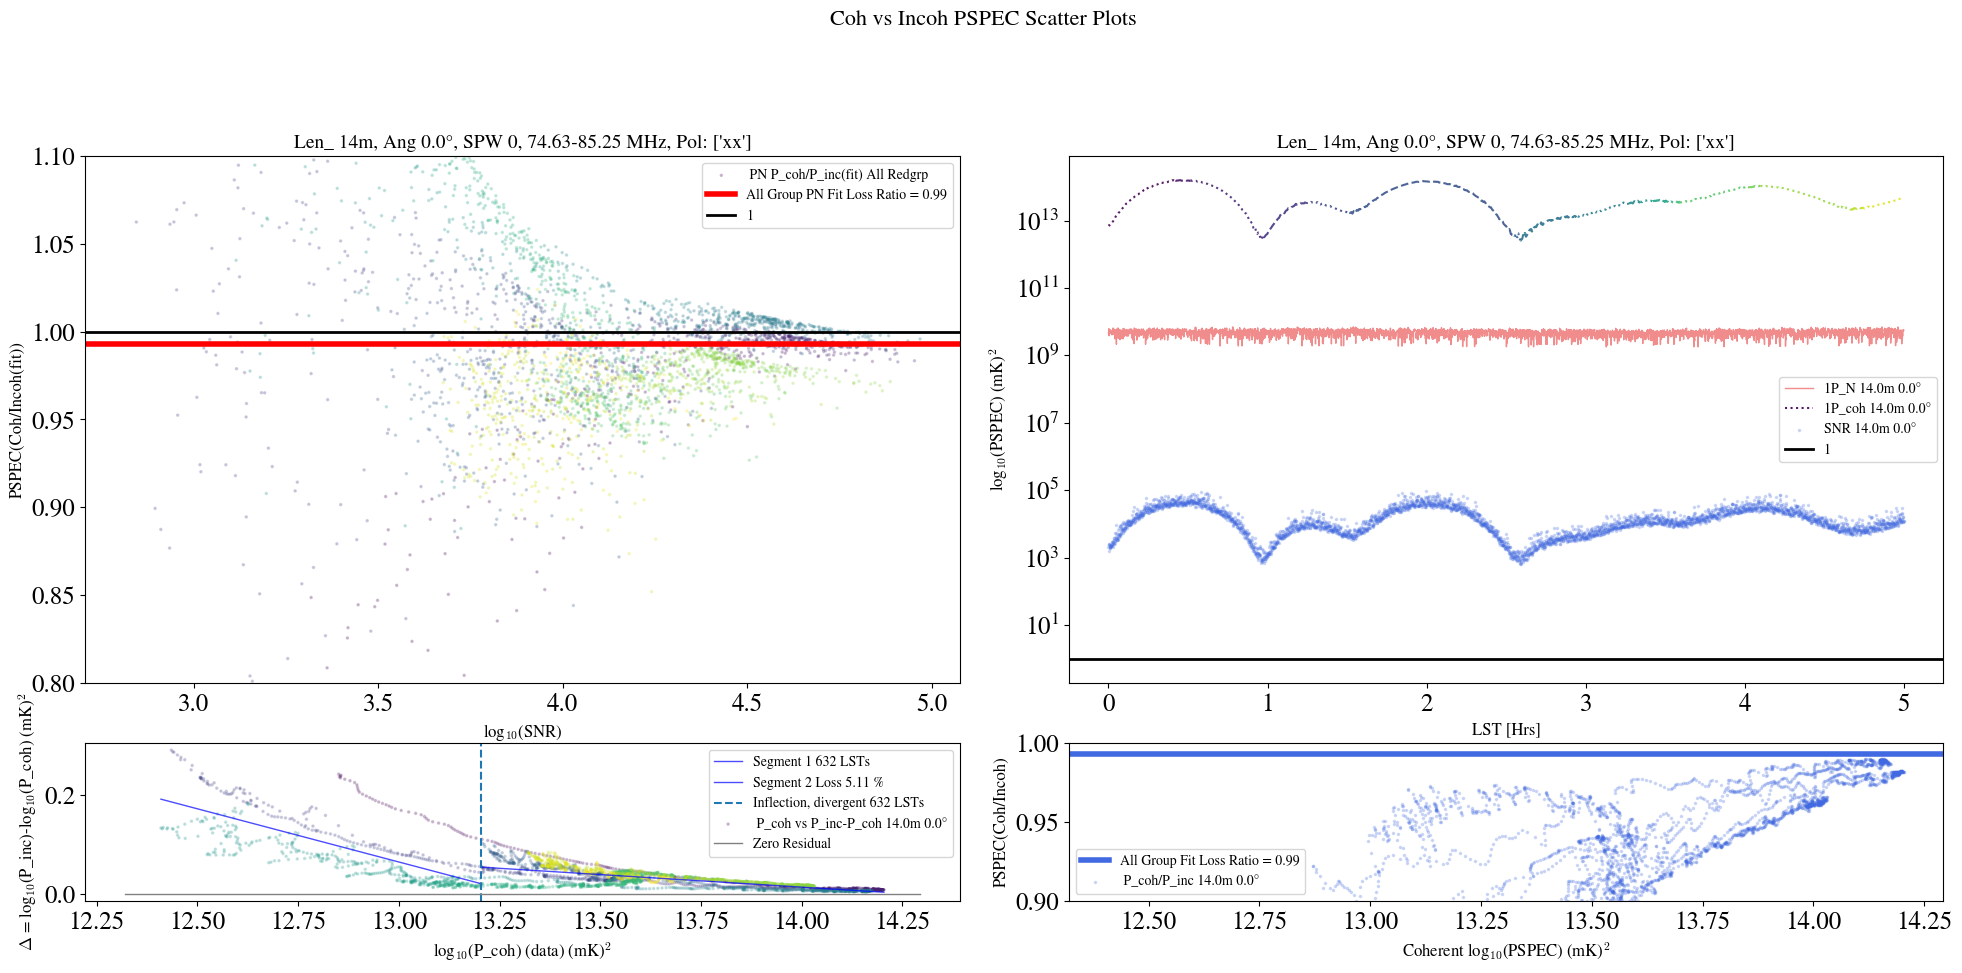

grp_median_vals  [0.705410018730257]
minmax SNR nsample  [['14.0m 0.0° 0spw: ', ('min SNR[LST]', 0.0, 0.32916750403195416), ('max SNR[LST]', 92811.09821058364, 1.997222854804655)]]


In [19]:
set_median_vals = []
maxmin_SNR_nsmp_perLST_perspw = []

bl_len = [14.0]#, 25, 25, 29, 29, 29, 39, 39, 39, 39, 44, 44, 44, 51, 51, 53, 53, 53, 53, 58, 58 ] 
bl_ang = [0.0]#, 150, 30, 0, 60, 120, 19, 161, 139, 41, 0, 60, 120, 30, 150, 166, 14, 46, 134, 0, 120 ] 

print(combined_uvp_dict.keys())
print("pol ", pol_root[0])

for i in range(0,len(bl_len)):
    grp_median_vals, minmax_SNR = plot_percent_difference_with_1hrbin(
        i,
        lst_array = uvp.lst_avg_array * (24 / (2 * np.pi)),  # LST in hours
        pol = pol_root,
        uvp = combined_uvp_dict[(bl_len[i],bl_ang[i], pol_root[0])], 
        uvpspec_averaged = combined_uvp_avg_dict[(bl_len[i],bl_ang[i], pol_root[0])] 
    )
    print("grp_median_vals ", grp_median_vals)
    set_median_vals.append(grp_median_vals)
    print("minmax SNR nsample ", minmax_SNR)
    maxmin_SNR_nsmp_perLST_perspw.append(minmax_SNR)

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


SPW 0: 2-line fit Loss -0.32%
pinc, pcoh  1921 1921
P_N fit N_a, P_slope  15.045575417206052 1.0085435964549654
P_N fit loss -0.85 %


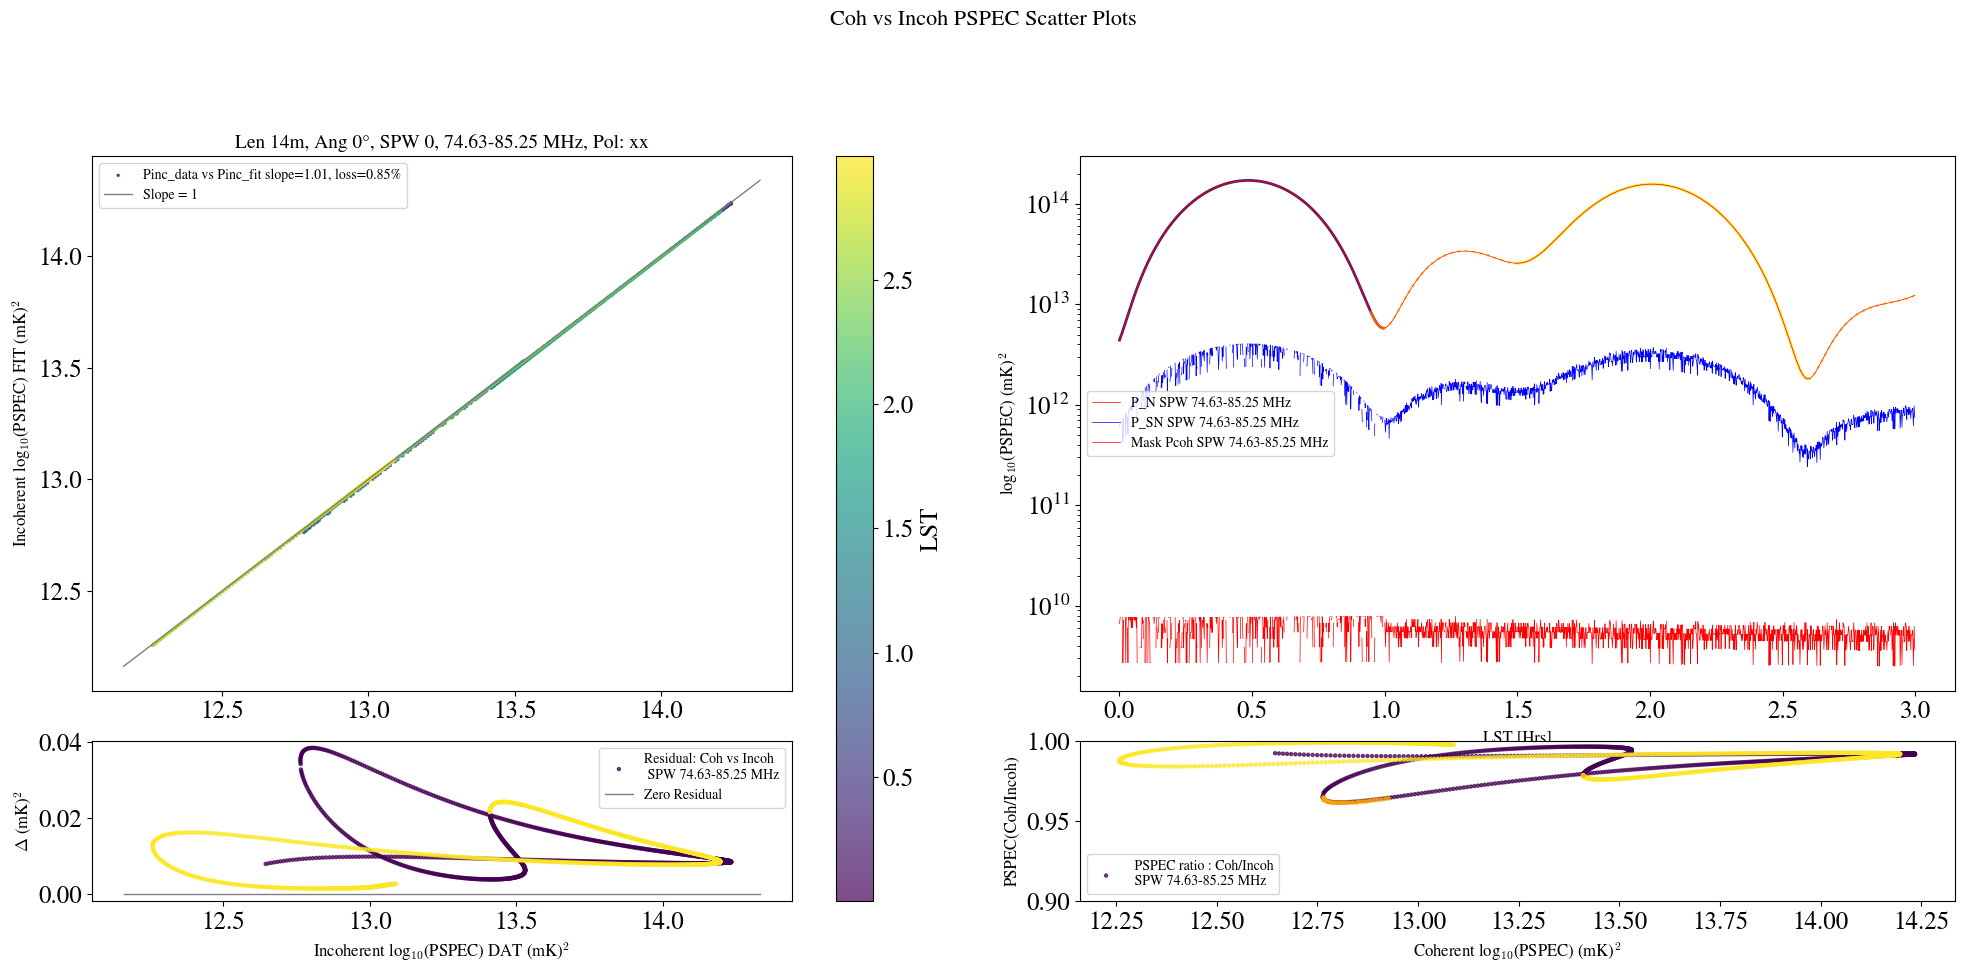

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator, FuncFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable



import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt

def piecewise_linear(params, x):
    """
    params = [m1, b1, m2, b2, x0]
    returns f(x) defined piecewise.
    """
    m1, b1, m2, b2, x0 = params
    return np.where(x <= x0,
                    m1 * x + b1,
                    m2 * x + b2)


def residuals(params, x, y):
    """Compute model minus data."""
    return piecewise_linear(params, x) - y

def fit_piecewise_linear(x, y, method='trf', manual_fallback=True):
    """
    Fit a two-segment piecewise linear model. By default uses TRF solver;
    if it fails and manual_fallback=True, falls back to grid search.
    Returns dict with slopes, intercepts, breakpoint, and diagnostics.
    """
    # initial guess & bounds
    p0 = [1.0, 0.0, 1.0, 0.0, np.median(x)]
    lower = [-np.inf, -np.inf, -np.inf, -np.inf, np.min(x)]
    upper = [ np.inf,  np.inf,  np.inf,  np.inf, np.max(x)]
    x_scale = np.array([1.0, 1.0, 1.0, 1.0, np.ptp(x)])
    diff_step = x_scale * 0.1

    try:
        result = least_squares(
            residuals, p0, args=(x, y), bounds=(lower, upper),
            method=method, x_scale=x_scale, diff_step=diff_step,
            ftol=1e-10, xtol=1e-10, gtol=1e-10
        )
        success = result.success
    except Exception:
        success = False
        result = None
        
    success=False

    if not success and manual_fallback:
        fit = manual_piecewise_linear_fit(x, y)
        fit['method'] = 'manual'
        return fit

    m1, b1, m2, b2, x0 = result.x
    return dict(
        m1=m1, b1=b1,
        m2=m2, b2=b2,
        x0=x0,
        success=result.success,
        cost=result.cost,
        nfev=result.nfev,
        message=result.message,
        method='trf'
    )

def manual_piecewise_linear_fit(x, y, num_breaks=200):
    """
    Brute-force grid search over breakpoints. Fits two segments via np.polyfit
    and selects breakpoint minimizing sum of squared errors.
    """
#     print("Doing manual")
    #print("x ", x)
    candidates = np.linspace(np.min(x), np.max(x), num_breaks)
    best = {'cost': np.inf}
    for x0 in candidates:
        # split
        left = x <= x0
        right = x > x0
        if np.sum(left) < 2 or np.sum(right) < 2:
            continue
        # fit segments
        m1, b1 = np.polyfit(x[left], y[left], 1)
        m2, b2 = np.polyfit(x[right], y[right], 1)
        # compute cost
        y_pred = np.empty_like(y)
        y_pred[left] = m1 * x[left] + b1
        y_pred[right] = m2 * x[right] + b2
        cost = np.sum((y_pred - y)**2)
        #print("cost ", cost)
        if cost < best['cost']:
            best.update(dict(m1=m1, b1=b1, m2=m2, b2=b2, x0=x0, cost=cost))
    return {**best, 'success': True, 'n_breaks': num_breaks}


def fit_linear_combo(y, fx, gx, snx=None):
    """
    Fit the model y ≈ a·f(x) + b·g(x) + c via ordinary least squares.

    Parameters
    ----------
    y  : array‐like, shape (N,)
        Observed dependent variable.
    fx : array‐like, shape (N,)
        First regressor f(x).
    gx : array‐like, shape (N,)
        Second regressor g(x).

    Returns
    -------
    a, b, c : floats
        Best‐fit coefficients such that y ≈ a·fx + b·gx + c.
    """
    y  = np.asarray(y,  float)
    fx = np.asarray(fx, float)
    gx = np.asarray(gx, float)
    
    # Build design matrix with columns [fx, gx, 1]
#     X = np.column_stack([fx, gx])#, np.ones_like(fx)])
    if snx is not None :
        snx = np.asarray(snx, float)
        X = np.column_stack([fx, gx, snx])#, np.ones_like(fx)])
    else:
        X = np.column_stack([fx, gx])#, np.ones_like(fx)])
    # Solve the normal equations: minimize ||X @ [a,b,c] – y||^2
#     (a, b, c), *_ = np.linalg.lstsq(X, y, rcond=None)
#     return a, b, c
    coefs = np.dot(np.linalg.pinv(X), y)
    return coefs



# Example usage:
# a, b, c = fit_linear_combo(y_array, f_of_x_array, g_of_x_array)

def predict_from_coeff(a, b, c, fx, gx):
# def predict_from_coeff(a, b, c, sn, fx, gx, snx):
    """
    Given fit coefficients a, b, c and your original regressors fx = f(x),
    gx = g(x), return the model prediction y_hat for each gx:
        y_hat = a*fx + b*gx + c

    Parameters
    ----------
    a, b, c : float
        Fitted coefficients.
    fx : array‐like, shape (N,)
        Values of f(x) at your sample points.
    gx : array‐like, shape (N,)
        Values of g(x) at your sample points.

    Returns
    -------
    y_hat : ndarray, shape (N,)
        The predicted y values, ready to plot versus gx.
    """
    fx = np.asarray(fx)
    gx = np.asarray(gx)
#     snx = np.asarray(snx)
    
    return a*fx + b*gx #+ c
#     return a*fx + b*gx + sn*snx #+ c


# Example usage:
# a, b, c = fit_linear_combo(y, fx, gx)
# y_pred = predict_from_g(a, b, c, fx, gx)
# plt.plot(gx, y_pred, '-', label='model vs g(x)')




def compute_1hr_bin_average(lst_array, data_array):
    """
    Compute a 1-hour bin average of data_array centered around each LST value.
    """
    data_array_1hrbin = np.zeros_like(data_array)
    lst_array_roll = np.where(lst_array > 20, lst_array - 24, lst_array)
    for i, lst in enumerate(lst_array_roll):
        # Find indices within ±0.5 hours of the current LST
        indices_in_bin = np.where((lst_array_roll >= lst - 0.5) & (lst_array_roll <= lst + 0.5))[0]
        # if( lst>0.001 and lst<0.002 ): 
            # print(" indices_in_bin ", lst_array[indices_in_bin] )
        if len(indices_in_bin) > 0:
            data_array_1hrbin[i] = np.nanmean(data_array[indices_in_bin])
        else:
            data_array_1hrbin[i] = np.nan
    return data_array_1hrbin

def get_spw_info(uvp):
    """
    Returns a dictionary mapping each SPW (from uvp.spw_array) to its (min, max) frequency range in Hz.
    """
    spw_indices = uvp.spw_array       # e.g., shape (14,)
    freq = uvp.freq_array             # e.g., shape (1114,)
    spw_freq = uvp.spw_freq_array     # e.g., shape (1114,)
    
    spw_info = {}
    for spw in spw_indices:
        mask = (spw_freq == spw)
        if np.any(mask):
            freq_min = np.min(freq[mask])
            freq_max = np.max(freq[mask])
            spw_info[spw] = (freq_min, freq_max)
        else:
            spw_info[spw] = None
    return spw_info

def get_plot_data(uvp, uvpspec_averaged, pol, idx):
    """
    Returns a dictionary mapping each spw index to its (min, max) frequency range (in Hz).
    """
    blp = uvp.get_blpairs()[0]
    # key = (idx, blp, 'xx')
    key = (idx, blp, pol)

    # Retrieve LST array and convert to hours.
    tarr = uvp.lst_avg_array
    tarrq = tarr * (12 / np.pi)  # Convert from radians to hours.
    lst_array_rad = tarr
#         print("lst_array_rad ", lst_array_rad)
    lst_array = tarrq

    dlys = uvp.get_dlys(idx) * 1e9
    index_of_zero = np.where(np.isclose(dlys, 0))[0][0]

    uvp_power = np.abs((uvp.get_data(key)))[:, index_of_zero]
    uvpspec_averaged_power = np.abs((uvpspec_averaged.get_data(key)))[:, index_of_zero]
    
    uvpspec_averaged_noise = np.abs(uvpspec_averaged.get_stats('autos_diag',key))[:, index_of_zero]
    
    uvp_power_S = (uvp.get_data(key))[:, index_of_zero].real

    percent_diff = 100 * (uvp_power - uvpspec_averaged_power) / np.where(uvpspec_averaged_power != 0, uvpspec_averaged_power, np.nan)
    median_val = np.nanmedian(percent_diff)
    median_vals.append(median_val)
    mean_val = np.nanmean(percent_diff)
    mean_vals.append(mean_val)

    lst_array_roll = np.where(lst_array > 20, lst_array - 24, lst_array)
        
    return dlys, index_of_zero, lst_array_rad, lst_array, lst_array_roll, uvp_power, uvpspec_averaged_power, uvpspec_averaged_noise, uvp_power_S, percent_diff, mean_vals

median_vals = []
mean_vals = []


def plot_percent_difference_with_1hrbin(lst_array, pol, uvp, uvpspec_averaged,
                                        zero_delay_pspec_spw=None, avg_pspec=None):
    """
    Plot percent difference (using 1-hr bin averages) between uvp and uvpspec_averaged versus LST for each SPW.
    
    For each SPW, the plot has two main axes (with corresponding residual axes below):
      - Main scatter plots (for full data and 1-hr binned data)
      - Residual scatter plots (showing the difference on a log10 scale)
    
    Titles and legends include:
      - Baseline length (in m)
      - Baseline angle (forced to 0° here, while also showing the computed angle in degrees)
      - SPW index and its full frequency range (in MHz)
      - Polarization.
    """
    # Ensure the LST array is sorted (in hours)
    # lst_sorted_indices = np.argsort(lst_array)
    # lst_array = lst_array[lst_sorted_indices]
    
    # Retrieve SPW info from the UVP object
    spw_info = get_spw_info(combined_uvp_dict[(bl_len[0], bl_ang[0], pol)])  # Using the first baseline as reference
    
    num_spws = len(spw_info)
    fig, axes = plt.subplots(1, 2, figsize=(20, 10), sharex=False)
    axes = axes.flatten(order='C')
    
    # Create residual axes appended below each main axis
    residual_axes = []
    for ax in axes:
        divider = make_axes_locatable(ax)
        ax_res = divider.append_axes("bottom", size="30%", pad=0.5)
        residual_axes.append(ax_res)
        ax.tick_params(labelbottom=True)
    
    # --- Baseline Information ---
    bl_vec = combined_uvp_dict[(bl_len[0], bl_ang[0], pol) ].bl_vecs[0]  # using the first baseline vector
    baseline_length = np.linalg.norm(bl_vec)
    angle_rad = np.arctan2(bl_vec[1], bl_vec[0])
    baseline_angle_deg = np.degrees(angle_rad)
    forced_angle = 0  # Force to 0° if desired
    
    # --- Loop Over SPWs ---
    # Iterate over sorted spw_info items (by the key)
    for idx, (spw_key, spw_val) in enumerate(sorted(spw_info.items(), key=lambda x: x[0])):
        if spw_val is not None:
            freq_min, freq_max = spw_val
            freq_range_str = f"{freq_min/1e6:.2f}-{freq_max/1e6:.2f} MHz"
        else:
            freq_range_str = "N/A"
        
        # Data retrieval using a baseline pair (adjust as needed)
        blp = combined_uvp_dict[(bl_len[0], bl_ang[0], pol)].get_blpairs()[0]
        key = (idx, blp, 'xx')
        
#         for i in range(1):#len(bl_len)):
        i=0
        dlys, index_of_zero, lst_array_rad, lst_array, lst_array_roll, uvp_power, uvpspec_averaged_power, uvpspec_averaged_noise, uvp_power_S, percent_diff, mean_vals = get_plot_data(combined_uvp_dict[(bl_len[i], bl_ang[i], pol)], combined_uvp_avg_dict[(bl_len[i], bl_ang[i], pol)], pol, idx)
            
        P_SN = np.sqrt(np.sqrt(2) * uvp_power_S * np.sqrt(77)*uvpspec_averaged_noise + (np.sqrt(77)*uvpspec_averaged_noise)**2)
            
        # Valleys for threshold to peak range
        segs, dips, valleys, valleys2 = bump_n_val_segments_by_dips(
            lst_array_roll, uvp_power, uvpspec_averaged_power,
            smooth_window=51, polyorder=3,
            dip_prominence=1e10, dip_width=5,
            frac=0.05
        )
#         for i, (lseg, pseg) in enumerate(valleys):
#             print(f"Valley {i}: LST {lseg[0]:.3f} → {lseg[-1]:.3f}, {len(lseg)} points")

#         print(f"Found {len(segs)} bumps between dips at indices {dips}")
        
#         dlys = combined_uvp_dict[bl_len[0]].get_dlys(idx) * 1e9
#         index_of_zero = np.where(np.isclose(dlys, 0))[0][0]
        
#         uvp_power = np.abs(np.real(uvp.get_data(key)))[:, index_of_zero]
#         uvpspec_averaged_power = np.abs(np.real(uvpspec_averaged.get_data(key)))[:, index_of_zero]
        
#         uvp_power = uvp_power[lst_sorted_indices]
#         uvpspec_averaged_power = uvpspec_averaged_power[lst_sorted_indices]
        
        # Compute 1-hr bin averages
        uvpspec_averaged_power_1hrbin = compute_1hr_bin_average(lst_array, uvpspec_averaged_power)
        uvp_power_1hrbin = compute_1hr_bin_average(lst_array, uvp_power)
        
        # Compute percent differences:
        percent_diff = 100 * (uvp_power - uvpspec_averaged_power) / np.where(uvpspec_averaged_power_1hrbin != 0,
                                                                              uvpspec_averaged_power_1hrbin,
                                                                              np.nan)
        percent_diff_raw = 100 * (uvp_power - uvpspec_averaged_power) / np.where(uvpspec_averaged_power != 0,
                                                                                  uvpspec_averaged_power,
                                                                                  np.nan)
        
        median_val = np.nanmedian(percent_diff)
        mean_val = np.nanmean(percent_diff)
        
        # Group axes: use 2 main axes per SPW (and 2 corresponding residual axes)
        a = 4 * (idx // 2) + (idx % 2)
        b = a + 2
#         print((a, b))
#         ax_group = axes[idx:idx+1] 
        ax_group = axes[a:b+1] # axes[2*idx:(2*idx)+2]
#         ax_res_group = residual_axes[idx:idx+1] 
        ax_res_group = residual_axes[a:b+1] # residual_axes[2*idx:(2*idx)+2]
        
        # --- Main Scatter Plots ---
        
#         ax_group[-1].plot(lst_array_roll, uvp_power, linewidth=1, linestyle="-", color="blue", alpha=0.5,
#                    label=f"P_coh SPW {freq_range_str}")
        ax_group[-1].plot(lst_array_roll, uvpspec_averaged_noise, linewidth=0.5, linestyle="-", color="red",
                   label=f"P_N SPW {freq_range_str}")
        ax_group[-1].plot(lst_array_roll, P_SN, linewidth=0.5, linestyle="-", color="blue",
                   label=f"P_SN SPW {freq_range_str}")
        from itertools import cycle
#         color_cycle = cycle(['#1f77b4','#ff7f0e','#2ca02c','#d62728'])  # any palette
        style_cycle = cycle(['-',':'])  # any palette
        cmap = plt.cm.viridis
        n = len(segs) 
        n = 2

        for i,(lst_seg,ps_seg) in enumerate(segs):
#             print(f"--- bump #{i} spans LST = {lst_seg[0]:.2f} → {lst_seg[-1]:.2f}")
            ax_group[-1].plot(lst_seg, ps_seg, linestyle=next(style_cycle), #"-", 
                                 color=cmap(i/(n-1)), #next(color_cycle),
                                 linewidth=2,
                                 alpha=0.9)
        for i, (lseg, pseg) in enumerate(valleys):
            ax_group[-1].plot(lseg, pseg, linestyle="-", color='orange',
                       alpha=1)
            
        # SCATTER PLOT WITH FIT
        
        # 3) build an integer “segment index” for each point in your full lst_array
        segment_id = np.full_like(lst_array_roll, fill_value=-1, dtype=int)
        for i, (lst_seg, _) in enumerate(segs):
            # if segs gives you the exact LST values in each bump:
            mask = np.isin(lst_array_roll, lst_seg)
            # otherwise if lst_seg is a contiguous slice, you can do:
            # mask = (lst_array_roll >= lst_seg.min()) & (lst_array_roll <= lst_seg.max())
            segment_id[mask] = i
            
        # 4) grab a discrete OrRd with N colors
        from matplotlib import cm
        cmap_fit = cm.get_cmap('viridis', n)

        # 5) set up a norm so each integer picks its own block
        from matplotlib.colors import BoundaryNorm
        norm = BoundaryNorm(np.arange(n+1) - 0.5, n)
        
#         scatter1 = ax_group[0].scatter(np.log10(uvp_power), np.log10(uvpspec_averaged_power),
#                                        s=20, marker=".", linestyle="-",
#                                        label=f"Coh vs Incoh PSPEC\n SPW {freq_range_str}",
#                                        c=segment_id, #lst_array, 
#                                        cmap=cmap_fit, #'OrRd', 
#                                        alpha=0.7)
#         cbar = plt.colorbar(scatter1, ticks=np.arange(n))
#         cbar.set_label('bump index')
        
#         for i, ((_, pseg1), (_, pseg2)) in enumerate(zip(valleys, valleys2)):
# #             ax_group[-1].scatter(lseg, pseg, s=2, marker="o", linestyle="-", color='black',
# #                        alpha=1)
#             print("valleys", i, pseg1.shape, pseg2.shape)
#             ax_group[0].scatter(np.log10(pseg1), np.log10(pseg2),
#                                        s=20, marker=".", linestyle="-",
# #                                        label=f"Nulls PSPEC\n SPW {freq_range_str}",
# #                                        c=segment_id, #lst_array, 
#                                        color='orange', #'OrRd', 
#                                        alpha=1)

#         scatter2 = ax_group[0].scatter(np.log10(uvp_power+uvpspec_averaged_noise), np.log10(uvpspec_averaged_power),
#                                        s=20, marker=".", linestyle="-",
#                                        label=f"Coh vs Incoh PSPEC\n SPW {freq_range_str}",
#                                        c=lst_array, cmap='YlGn', alpha=0.7)
        
#         print("np.log10(uvp_power) ", (uvp_power))
#         print("np.log10(uvpspec_averaged_power) ", (uvpspec_averaged_power))
        mask = ~ (np.isneginf(np.log10(uvp_power)) | np.isneginf(np.log10(uvpspec_averaged_power)))
        xin = np.log10(uvp_power)[mask]
        yin = np.log10(uvpspec_averaged_power)[mask]
#         print("inputs ", xin, yin)
        fit = fit_piecewise_linear(xin, yin)
#         print(fit.keys() )
#         print(f"Method: {fit['method']}")
#         print(f"m1={fit['m1']:.3f}, b1={fit['b1']:.3f}")
#         print(f"m2={fit['m2']:.3f}, b2={fit['b2']:.3f}")
#         print(f"x0={fit['x0']:.3f}, cost={fit.get('cost',np.nan):.3f}")
        
        m1, b1 = fit['m1'], fit['b1']
        m2, b2 = fit['m2'], fit['b2']
        x0 = fit['x0']
        print(f"SPW {idx}: 2-line fit Loss {-1*(1-m2)*100:.2f}%")
        
        left_mask = xin < x0
        n_left   = np.count_nonzero(left_mask)
        n_total  = xin.size
        fraction = n_left / n_total

#         print(f"{n_left} points are to the left of x0 = {x0:.3f}, out of {n_total} total")
#         print(f"Fraction left of breakpoint = {fraction:.2%}")
        
        inp_x = xin #np.log10(uvp_power)
        x_min, x_max = np.min(inp_x), np.max(inp_x)
        x1 = np.linspace(x_min, x0, 200)
        x2 = np.linspace(x0, x_max, 200)
#         ax_group[0].plot(x1, m1*x1 + b1, linewidth=1, label=f'Segment 1 {n_left} LSTs', color='blue', alpha=0.7 )
#         ax_group[0].plot(x2, m2*x2 + b2, linewidth=1, label=f'Segment 2 Loss {(1-m2)*100:.2f} %', color='blue', alpha=0.7 )
#         ax_group[0].axvline(x0, linestyle='--', label=f'Inflection, divergent {n_left} LSTs') # x0={x0:.2f}')
        
        NaN_mask = np.isfinite(uvpspec_averaged_power) & np.isfinite(uvpspec_averaged_noise) & np.isfinite(uvp_power)
        pinc = uvpspec_averaged_power[NaN_mask]
        P_N = uvpspec_averaged_noise[NaN_mask]
        pcoh = uvp_power[NaN_mask]
        P_SN_in = P_SN[NaN_mask]
        cond = np.linalg.cond(np.column_stack([P_N, pcoh]))
#         print("Condition number:", cond)
        c=1
        print("pinc, pcoh ", len(pinc), len(pcoh))
    
        na, slopeloss = fit_linear_combo(y=pinc, fx=P_N, gx=pcoh)
#         na, slopeloss, sn = fit_linear_combo(pinc, P_N, pcoh, P_SN_in)
    
        print("P_N fit N_a, P_slope ", na, slopeloss)
#         print("P_N fit N_a, P_slope ", na, slopeloss, sn)
    
        print(f"P_N fit loss {-1*(1-(1/slopeloss))*100:.2f} %")
        
        pinc_pred = predict_from_coeff(na, slopeloss, c, P_N, pcoh)
#         pinc_pred = predict_from_coeff(na, slopeloss, c, sn, P_N, pcoh, P_SN_in)
    
#         scatter1 = ax_group[0].scatter(np.log10(pcoh), np.log10(pinc_pred), s=2, linewidth=1, label=f'P_N Fit slope={slopeloss:.2f}, loss={(slopeloss-1)*100:.2f}%', color='red', alpha=0.6,) 
#                             c=lst_array_roll[NaN_mask], cmap='viridis' )
        # scatter2 = ax_group[0].scatter(np.log10(pinc), np.log10(pinc_pred), s=2, linewidth=1, label=f'Pinc_data vs Pinc_fit slope={slopeloss:.2f}, loss={(slopeloss-1)*100:.2f}%',  alpha=0.7, 
        #                     c=lst_array_roll[NaN_mask], cmap='viridis' )
        scatter2 = ax_group[0].scatter(np.log10(pinc), np.log10(pcoh), s=2, linewidth=1, label=f'Pinc_data vs Pinc_fit slope={slopeloss:.2f}, loss={(slopeloss-1)*100:.2f}%',  alpha=0.7, 
                            c=lst_array_roll[NaN_mask], cmap='viridis' )
        
        cbar = plt.colorbar(scatter2)#, ticks=np.arange(12))
        cbar.set_label('LST')
        
        ax_group[-1].plot(lst_array_roll[NaN_mask], pcoh, linewidth=0.5, linestyle="-", color="red",
                   label=f"Mask Pcoh SPW {freq_range_str}")
        
#         left_mask = np.log10(pcoh) < x0
#         n_left   = np.count_nonzero(left_mask)
#         ax_group[0].axvline(x0, linestyle='--', label=f'Inflection, divergent {n_left} LSTs') # x0={x0:.2f}')
        
        
#         cbar1 = fig.colorbar(scatter1, ax=ax_group[0])
#         cbar1.set_label("LST (Hr)", fontsize=12)
    
        
#         scatter2 = ax_group[-1].scatter(np.log10(uvp_power_1hrbin), np.log10(uvpspec_averaged_power_1hrbin),
#                                        s=20, marker=".", linestyle="-",
#                                        label=f"1Hr Coh vs 1Hr Incoh PSPEC\n SPW {freq_range_str}",
#                                        c=lst_array, cmap='OrRd', alpha=0.7)
#         cbar2 = fig.colorbar(scatter2, ax=ax_group[-1])
#         cbar2.set_label("LST (Hr)", fontsize=12)
        
        # --- Residual Scatter Plots ---
        scatter_res1 = ax_res_group[0].scatter(
                                               np.log10(uvp_power), 
                                            #    np.log10(uvpspec_averaged_power)-np.log10(uvp_power),
                                               (uvpspec_averaged_power-uvp_power)/uvpspec_averaged_power,
                                               s=20, marker=".", linestyle="-",
                                               label=f"Residual: Coh vs Incoh\n SPW {freq_range_str}",
                                               c=segment_id, cmap=cmap_fit, alpha=0.7)
#         scatter_res2 = ax_res_group[-1].scatter(np.log10(uvp_power_1hrbin), np.log10(uvpspec_averaged_power_1hrbin)-np.log10(uvp_power_1hrbin),
#                                                s=20, marker=".", linestyle="-",
#                                                label=f"Residual 1hr: Coh vs Incoh\n SPW {freq_range_str}",
#                                                c=lst_array, cmap='OrRd', alpha=0.7)
        scatter_res2 = ax_res_group[-1].scatter(np.log10(uvp_power), (uvp_power/uvpspec_averaged_power),
                                               s=20, marker=".", linestyle="-",
                                               label=f" PSPEC ratio : Coh/Incoh\n SPW {freq_range_str}",
                                               c=segment_id, cmap=cmap_fit, alpha=0.7)
    
        for i, ((_, pseg1), (_, pseg2)) in enumerate(zip(valleys, valleys2)):
#             print("valleys", i, pseg1.shape, pseg2.shape)
            ax_res_group[-1].scatter(np.log10(pseg1), (pseg1/pseg2),
                                               s=20, marker=".", linestyle="-",
#                                                label=f" PSPEC ratio : Coh/Incoh\n SPW {freq_range_str}",
                                               color='orange', alpha=0.7)
        
        # --- Overlay Subset Points (where uvp_power > uvpspec_averaged_power) ---
        mask_full = uvp_power > uvpspec_averaged_power
        subset_uvp_power = uvp_power[mask_full]
        subset_uvpspec_averaged_power = uvpspec_averaged_power[mask_full]
        
        mask_1hr = uvp_power_1hrbin > uvpspec_averaged_power_1hrbin
        subset_uvp_power_1hrbin = uvp_power_1hrbin[mask_1hr]
        subset_uvpspec_averaged_power_1hrbin = uvpspec_averaged_power_1hrbin[mask_1hr]
        
#         ax_group[0].scatter(np.log10(subset_uvp_power), np.log10(subset_uvpspec_averaged_power),
#                             s=100, marker="o", facecolors='none', edgecolors='r', linewidth=1.5,
#                             label=f"UVP > UVPSPEC ({np.sum(mask_full)})")
#         ax_group[1].scatter(np.log10(subset_uvp_power_1hrbin), np.log10(subset_uvpspec_averaged_power_1hrbin),
#                             s=100, marker="o", facecolors='none', edgecolors='r', linewidth=1.5,
#                             label=f"UVP > UVPSPEC 1hrBin ({np.sum(mask_1hr)})")
        
        # --- Add Diagonal (Slope=1) Lines to Main Axes ---
        line_x1 = np.linspace(*ax_group[0].get_xlim(), num=100)
        ax_group[0].plot(line_x1, line_x1, linestyle='-', color='gray', label='Slope = 1', linewidth=1)
#         line_x2 = np.linspace(*ax_group[-1].get_xlim(), num=100)
#         ax_group[-1].plot(line_x2, line_x2, linestyle='-', color='gray', label='Slope = 1', linewidth=1)
        
        # --- Add Zero Lines to Residual Axes ---
        line_rx1 = np.linspace(*ax_res_group[0].get_xlim(), num=100)
        ax_res_group[0].plot(line_rx1, 0*line_rx1, linestyle='-', color='gray', label='Zero Residual', linewidth=1)
#         line_rx2 = np.linspace(*ax_res_group[-1].get_xlim(), num=100)
#         ax_res_group[-1].plot(line_rx2, 0*line_rx2, linestyle='-', color='gray', label='Zero Residual', linewidth=1)
        
        # --- Synchronize Limits for Main Axes ---
        xlim = ax_group[0].get_xlim()
        ylim = ax_group[0].get_ylim()
        overall_min = min(xlim[0], ylim[0])
        overall_max = max(xlim[1], ylim[1])
        ax_group[0].set_xlim(overall_min, overall_max)
        ax_group[0].set_ylim(overall_min, overall_max)
        
        # --- Set Labels for Main Axes ---
        ax_group[0].set_ylabel(r'Incoherent log$_{10}$(PSPEC) FIT (mK)$^2$', fontsize=12)
        ax_res_group[0].set_xlabel(r'Incoherent log$_{10}$(PSPEC) DAT (mK)$^2$', fontsize=12)
        ax_res_group[0].set_ylabel(r'$\Delta$ (mK)$^2$', fontsize=12)
        
        ax_group[-1].set_ylabel(r'log$_{10}$(PSPEC) (mK)$^2$', fontsize=12)
        ax_group[-1].set_yscale('log')
        ax_group[-1].set_xlabel(r'LST [Hrs]', fontsize=12)
        ax_res_group[-1].set_xlabel(r'Coherent log$_{10}$(PSPEC) (mK)$^2$', fontsize=12)
        ax_res_group[-1].set_ylabel(r'PSPEC(Coh/Incoh)', fontsize=12)
        ax_res_group[-1].set_ylim(0.9, 1)
        
        # --- Set Titles and Legends (Using Baseline and Frequency Info) ---
        title_str = (f"Len {int(baseline_length)}m, Ang {forced_angle}°, "
                     f"SPW {idx}, {freq_range_str}, Pol: {pol}")
        ax_group[0].set_title(title_str, fontsize=14)
#         ax_group[-1].set_title(title_str, fontsize=14)
        ax_group[0].legend(fontsize=10)
        ax_group[-1].legend(fontsize=10)
        ax_res_group[0].legend(fontsize=10)
        ax_res_group[-1].legend(fontsize=10)
        
        ax_group[0].grid(False)
#         ax_group[-1].grid(False)
    
    # Hide unused subplots.
    # for idx in range(len(spw_info)*2, len(axes)):
    #     fig.delaxes(axes[idx])
    # for idx in range(len(spw_info)*2, len(residual_axes)):
    #     fig.delaxes(residual_axes[idx])
    
    fig.suptitle("Coh vs Incoh PSPEC Scatter Plots", fontsize=16)
    # plt.tight_layout()
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# Example usage:
plot_percent_difference_with_1hrbin(
    lst_array = uvp.lst_avg_array * (24 / (2 * np.pi)),  # LST in hours
    pol = 'xx',
    uvp = combined_uvp_dict,
    uvpspec_averaged = combined_uvp_avg_dict
)
